# Comparative Sentiment Classification of Airline Customer Feedback

**Case Study Part 1: Classical Machine Learning and Neural Approaches**

**Author:** Albert Kabore, PhD Student in AI


## Introduction and Research Objectives

### Research Objectives and Analytical Scope

This study compares sentiment classifiers for airline customer feedback and evaluates their usefulness for complaint review and sentiment monitoring. It examines preprocessing choices, sparse and dense text representations, class-specific errors, and the limits of business conclusions drawn from historical social-media data.


Customer feedback can help airlines identify service concerns and prioritize responses. This research uses the existing Twitter US Airline Sentiment dataset to classify tweets as negative, neutral or positive and compare approaches for short customer-feedback text. Its objectives are to evaluate classification performance and examine how sentiment predictions could support complaint triage and service monitoring.

The workflow includes text cleaning, tokenization, lemmatization and stop-word removal while retaining negation cues. TF-IDF and Word2Vec features support classical models, which are compared with a BiLSTM. Accuracy, precision, recall and F1-score are assessed on a shared test set. Transformer code is included as an optional extension; completed Transformer results are unavailable.


## 0. Computational Environment and Experimental Configuration


### 0.1 Training Controls and Hyperparameter Search Configuration


In [1]:
# --- Run-time switches -------------------------------------------------------
RUN_GRID_SEARCH = False    # True → re-run 5-fold grid search for every classical model (~20 min)
TRAIN_BILSTM = False       # True → train the BiLSTM here instead of loading saved predictions
TRAIN_TRANSFORMER = False  # True → fine-tune DistilRoBERTa here (~1 h on CPU, needs ~3 GB free RAM)

### 0.2 Library Imports and Project Initialization


In [2]:
import json
import sys
import time
import warnings
from pathlib import Path

# Make the project root importable whether Jupyter was started in the root or in notebooks/.
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src import config, eda, evaluation as ev, insights
from src.classical_models import decision_scores, get_model_specs, tune_and_fit
from src.data_loading import clean_dataset, load_raw, split_data, summary_statistics
from src.features import Word2VecVectorizer, project_feature_space, word_tfidf
from src.plotting import MODEL_ORDER
from src.preprocessing import TweetPreprocessor, light_clean, normalize_tweet

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

config.ensure_dirs()
config.set_seed()
FIG, MET = config.FIGURES_DIR, config.METRICS_DIR


def show(path, width=760):
    # Every plotting helper in src/ saves a PNG; display the saved file inline.
    display(Image(filename=str(path), width=width))


print(f"Project root: {ROOT}\nRandom seed: {config.SEED}")

Project root: C:\Users\alber\Case_Study_Part_1_Sentiment-Analysis-for-Customer-Feedback
Random seed: 42


## 1. Dataset Provenance and Exploratory Data Analysis

The study uses the existing **Twitter US Airline Sentiment** dataset (Figure Eight, 2015), distributed on [Kaggle](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment). The source file contains 14,640 tweets about six US airlines, collected in February 2015. Human annotations provide negative, neutral, and positive labels, annotation confidence, and complaint reasons for negative tweets.

The airline industry provides a suitable setting because feedback includes service interactions, delays, cancellations, and baggage concerns. Tweets are short customer-feedback messages rather than conventional product reviews. The dataset includes all three required sentiment classes, although their frequencies are unequal. No new feedback was collected for this study.


### 1.1 Dataset Loading and Record Cleaning


In [3]:
raw = load_raw()
df, cleaning_report = clean_dataset(raw)
print(f"Raw rows: {len(raw):,}  →  clean rows: {len(df):,}")
pd.Series(cleaning_report, name="count").to_frame()

Raw rows: 14,640  →  clean rows: 14,485


,count
raw_rows,14640
duplicate_rows_removed,155
duplicate_ids_with_conflicting_labels,18
airline_rows_relabelled,2222
clean_rows,14485


### 1.2 Data Cleaning Findings and Annotation Ambiguity

- Removing 155 duplicate rows reduces the dataset from 14,640 to 14,485 tweets. The report also identifies 18 duplicate IDs with conflicting labels, so deduplication involves annotation ambiguity as well as repeated records.
- The 2,222 airline relabelings affect airline-level comparisons. Interpret those comparisons alongside the Delta-to-JetBlue mapping assumption documented in the limitations.


### 1.3 Reproducible Inspection of Customer Feedback


In [4]:
df[["tweet_id", "airline", "airline_sentiment", "airline_sentiment_confidence", "negativereason", "text"]].sample(8, random_state=config.SEED)

,tweet_id,airline,airline_sentiment,airline_sentiment_confidence,negativereason,text
8709,569629819559747585,United,negative,1.0,Customer Service Issue,@united why are your agents working so slowly to rebook people who are on #UA1481. We have all wasted an entire day ...
6501,569269757293293568,US Airways,negative,1.0,Can't Tell,@USAirways @AmericanAir 9 empty seats open in 1st on AA1061. No upgrades for a U.S. Gold member? Would love consiste...
2366,568196466503770112,JetBlue,negative,1.0,Late Flight,@JetBlue the big board says we aren't leaving until after 8:30 😩
6291,569239947061927938,JetBlue,positive,1.0,NaN,"@JetBlue thanks so much for help Us, u r amazing!"
169,567732946241470464,US Airways,negative,1.0,Customer Service Issue,@USAirways still crickets from customer service.
2034,568137557935960066,Southwest,positive,1.0,NaN,@SouthwestAir once or twice a year. Hard to get vacation time from work sometimes. But love flying with you guys!
12867,570059381284302848,Southwest,negative,1.0,Late Flight,@SouthwestAir here is my conf #F8NEQM. My flight was delayed for 3 hours while my friend waited for me on her bday. ...
1944,568117667879628800,United,negative,1.0,Bad Flight,@united your overall experience of flying is not friendly


### 1.4 Descriptive Statistics and Dataset Composition


In [5]:
tables = summary_statistics(df)
display(Markdown("**Dataset overview**"), tables["overview"])
display(Markdown("**Sentiment distribution**"), tables["sentiment"])
display(Markdown("**Sentiment by airline**"), tables["by_airline"])
display(Markdown("**Negative-tweet reasons**"), tables["negative_reasons"])

**Dataset overview**

,value
Tweets,14485
Airlines,6
First tweet (UTC),2015-02-17
Last tweet (UTC),2015-02-24
Mean words per tweet,17.7
Median words per tweet,19
Mean annotator confidence,0.901
% tweets with confidence < 1,28.5


**Sentiment distribution**

,count,percent
airline_sentiment,,
negative,9084,62.7
neutral,3067,21.2
positive,2334,16.1


**Sentiment by airline**

airline_sentiment,negative,neutral,positive,total,% negative
airline,,,,,
United,2633,697,492,3822,68.9
US Airways,2263,381,269,2913,77.7
American,1866,431,307,2604,71.7
Southwest,1186,664,570,2420,49.0
JetBlue,955,723,544,2222,43.0
Virgin America,181,171,152,504,35.9


**Negative-tweet reasons**

,count,percent
negativereason,,
Customer Service Issue,2883,31.7
Late Flight,1652,18.2
Can't Tell,1183,13.0
Cancelled Flight,831,9.1
Lost Luggage,718,7.9
Bad Flight,573,6.3
Flight Booking Problems,521,5.7
Flight Attendant Complaints,473,5.2
longlines,176,1.9


### 1.5 Class Imbalance, Sampling Coverage, and Annotation Confidence

- Negative tweets account for 62.7% of the sample; an always-negative classifier would therefore achieve approximately 62.7% accuracy. Macro-F1 and class-specific recall are needed to assess performance beyond this majority-class baseline.
- US Airways has the highest observed negative share (77.7%) and Virgin America the lowest (35.9%), but tweet volumes differ substantially (2,913 versus 504). These are proportions among sampled tweets, not population-wide airline satisfaction estimates.
- Customer Service Issue (31.7%) and Late Flight (18.2%) together represent 49.9% of negative-reason annotations. The 13.0% labelled *Can't Tell* also shows that complaint categorization is incomplete.
- The sample covers February 17?24, 2015, and 28.5% of tweets have annotator confidence below 1. Short duration and label uncertainty limit generalization.


### 1.6 Exploratory Visualization of Sentiment and Complaint Patterns


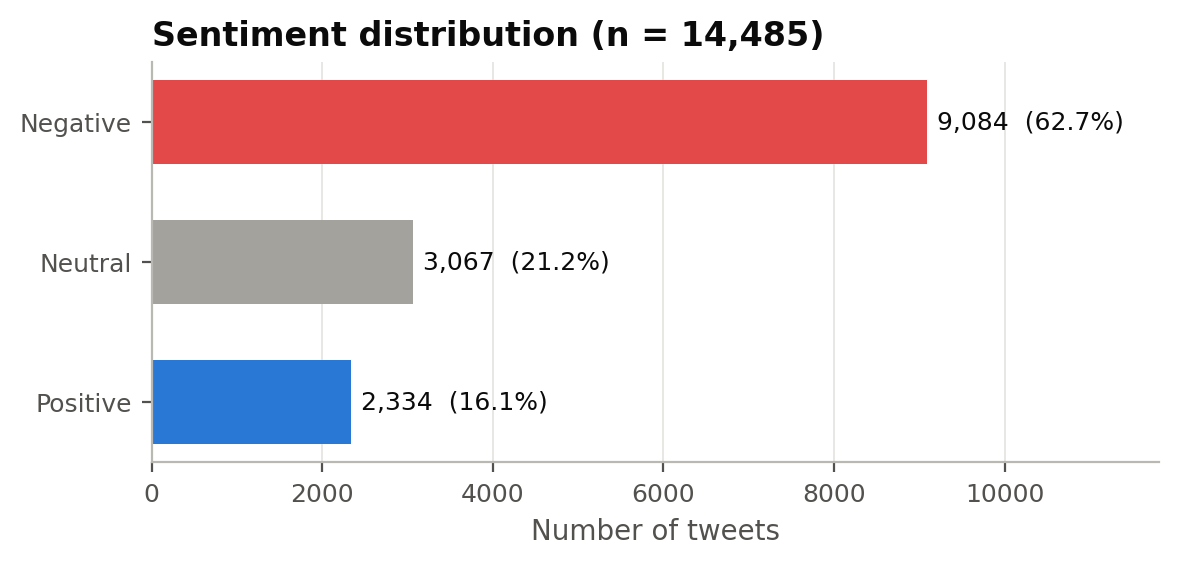

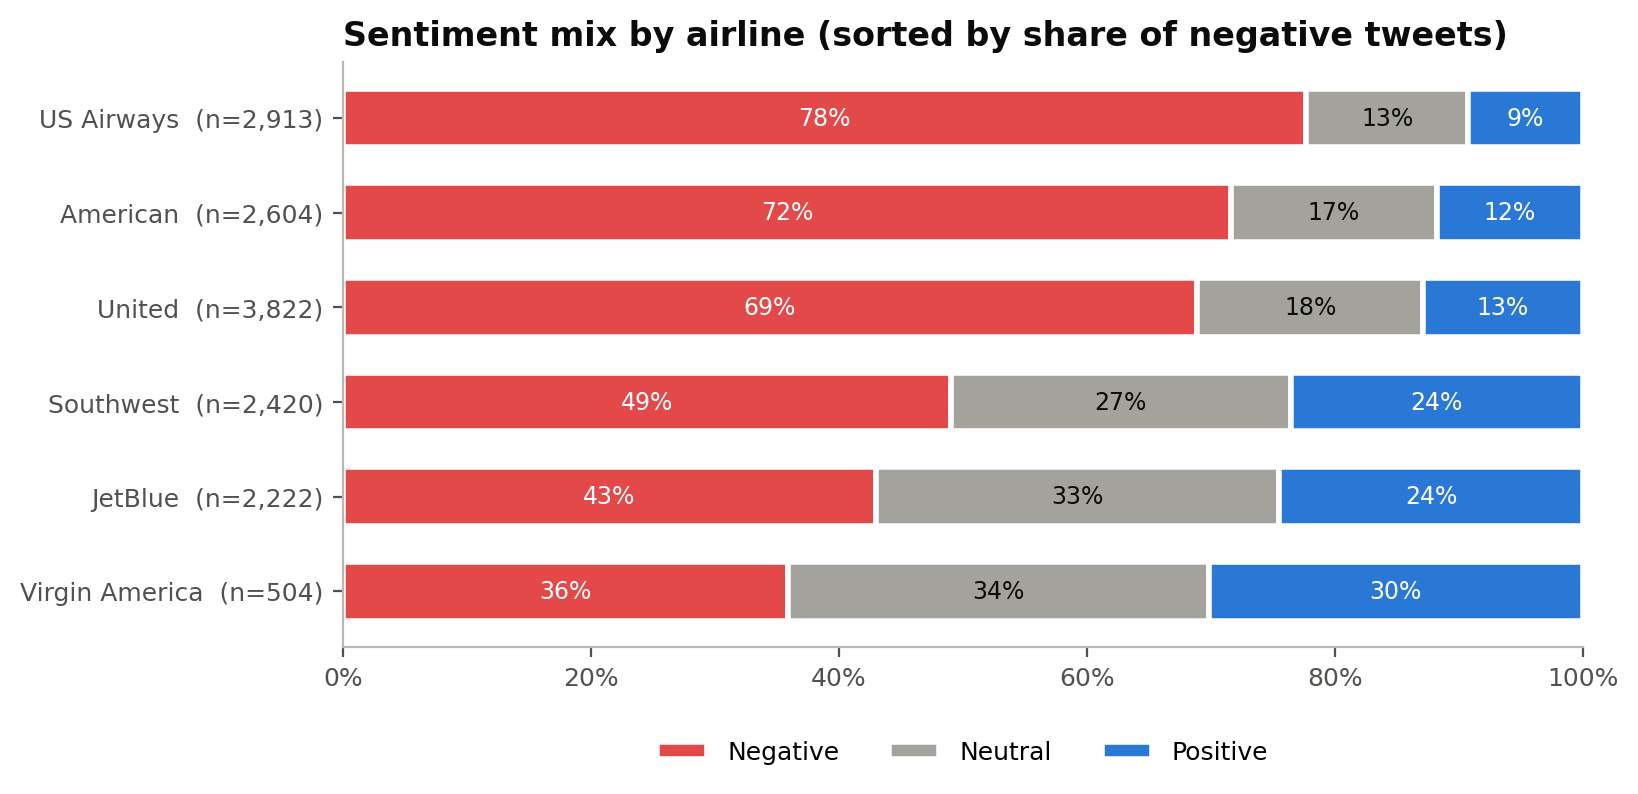

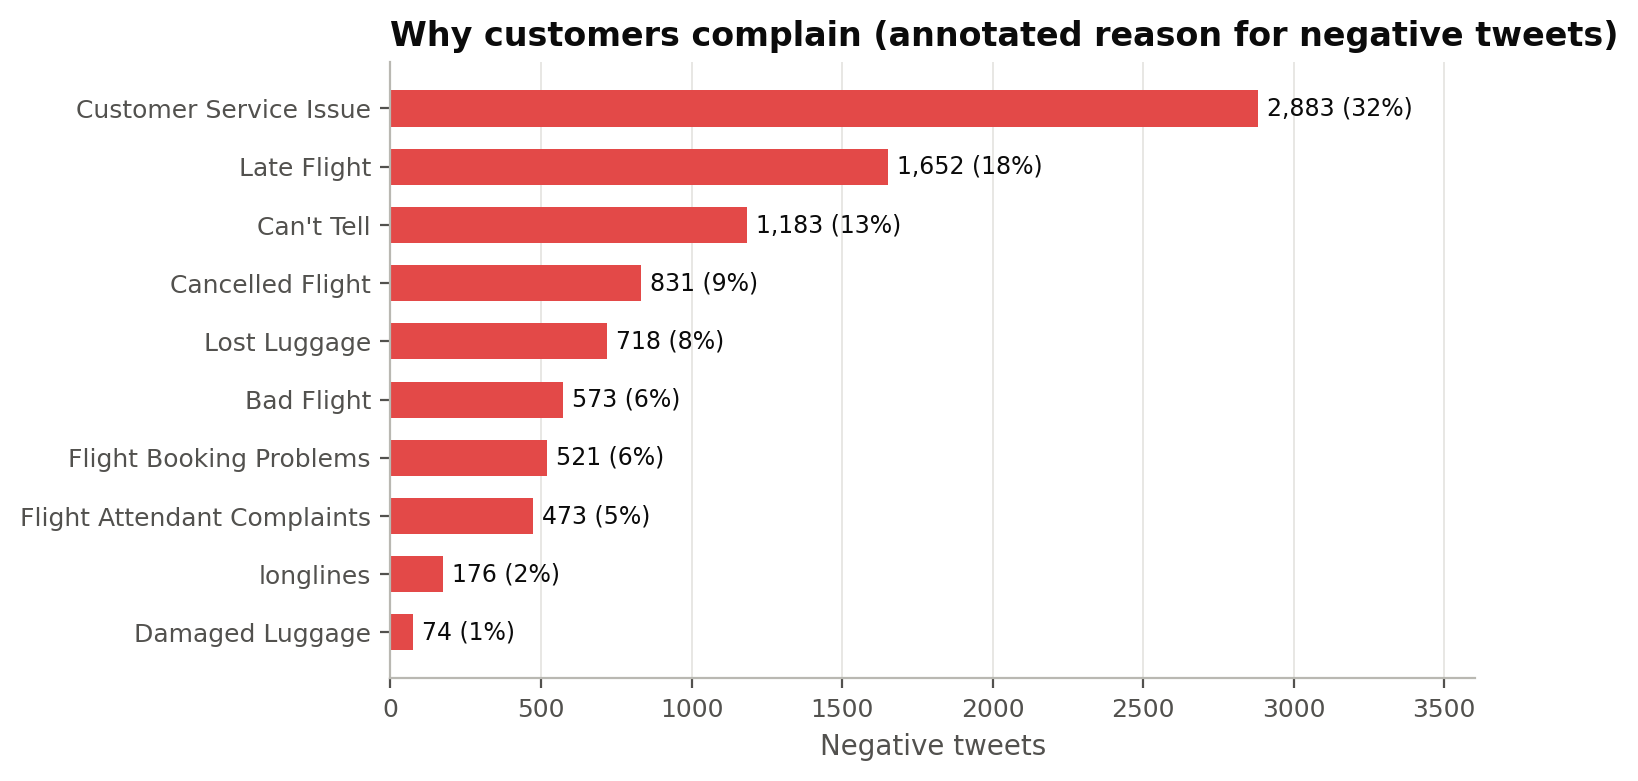

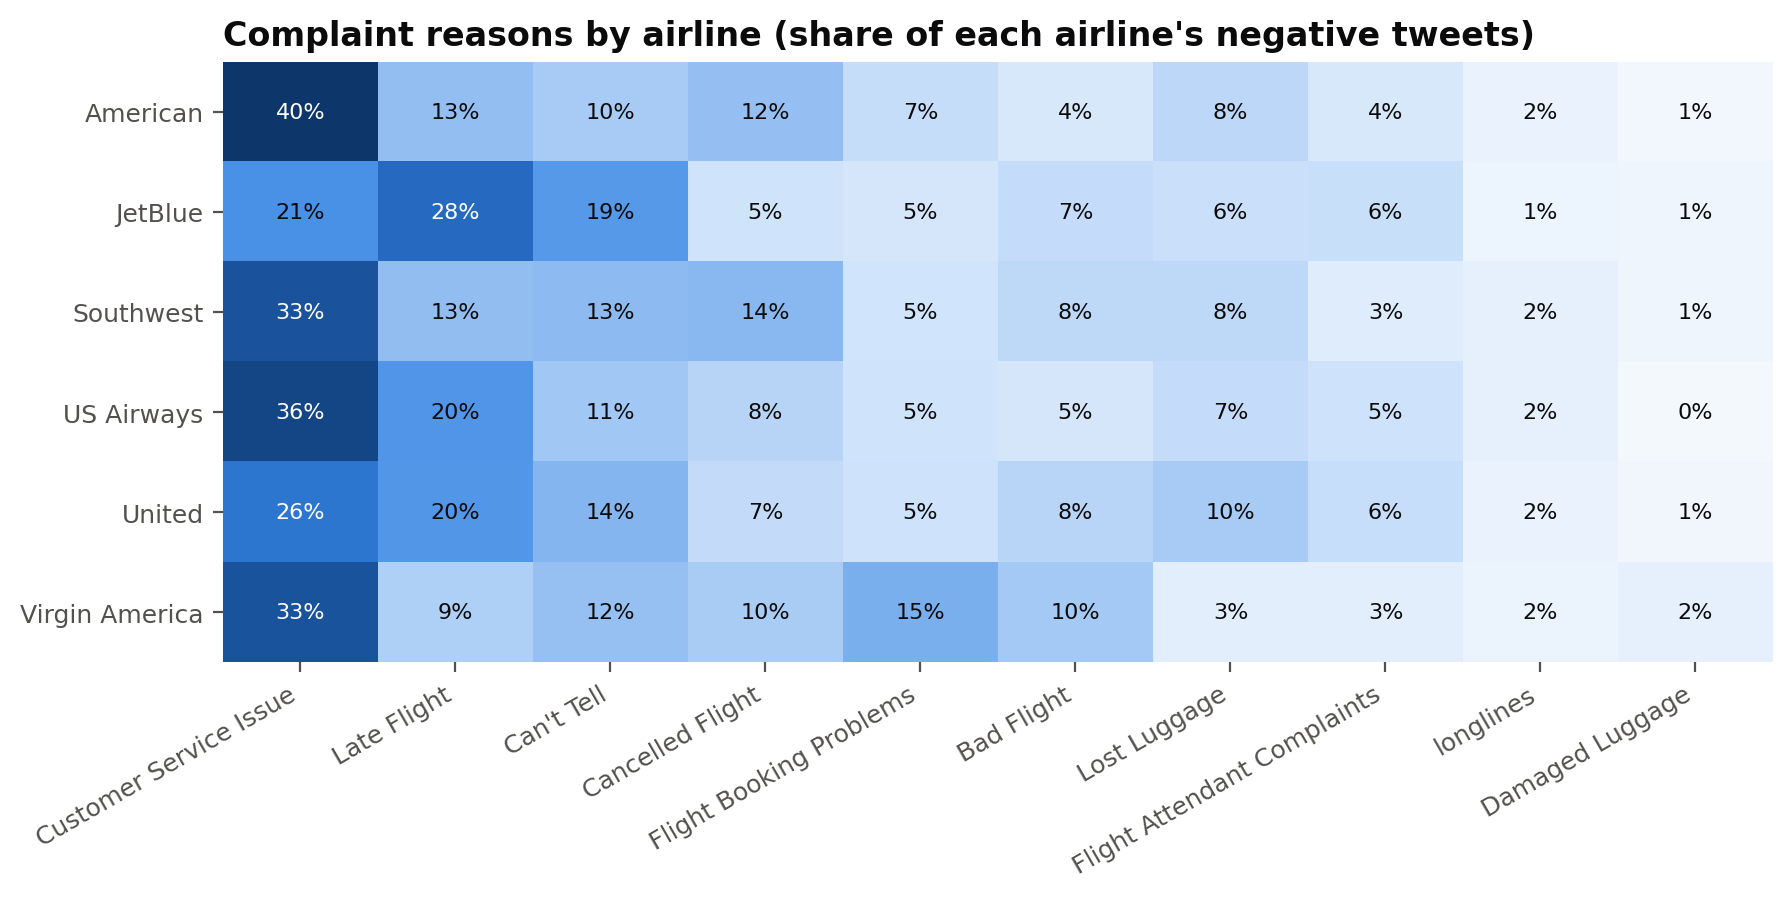

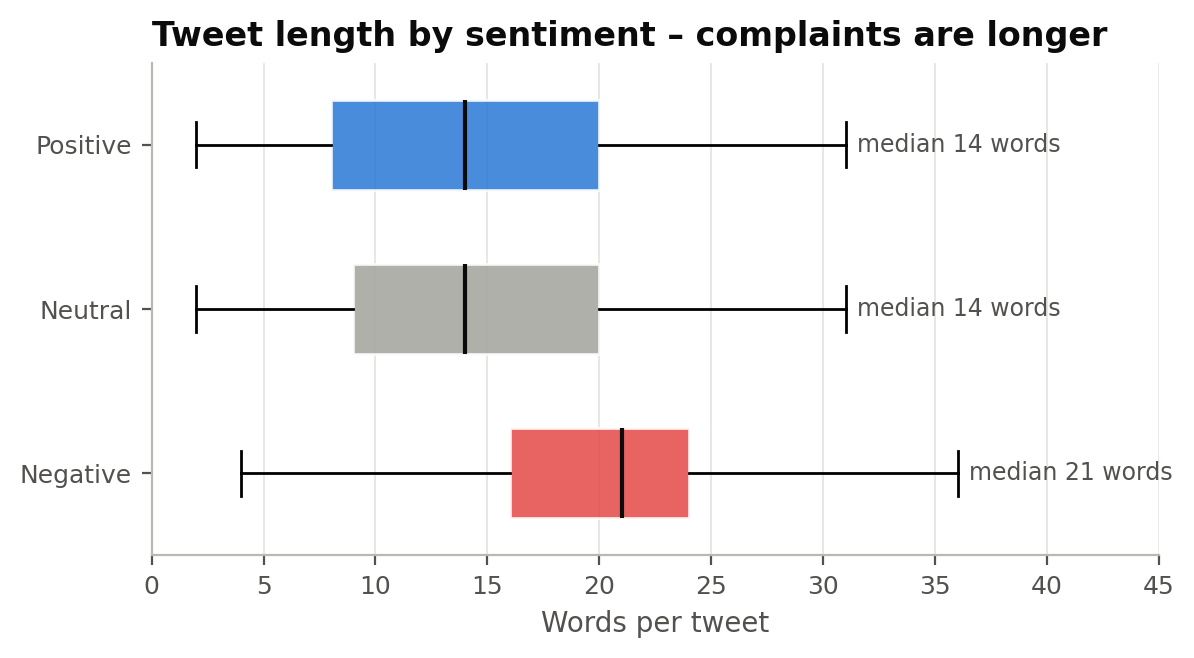

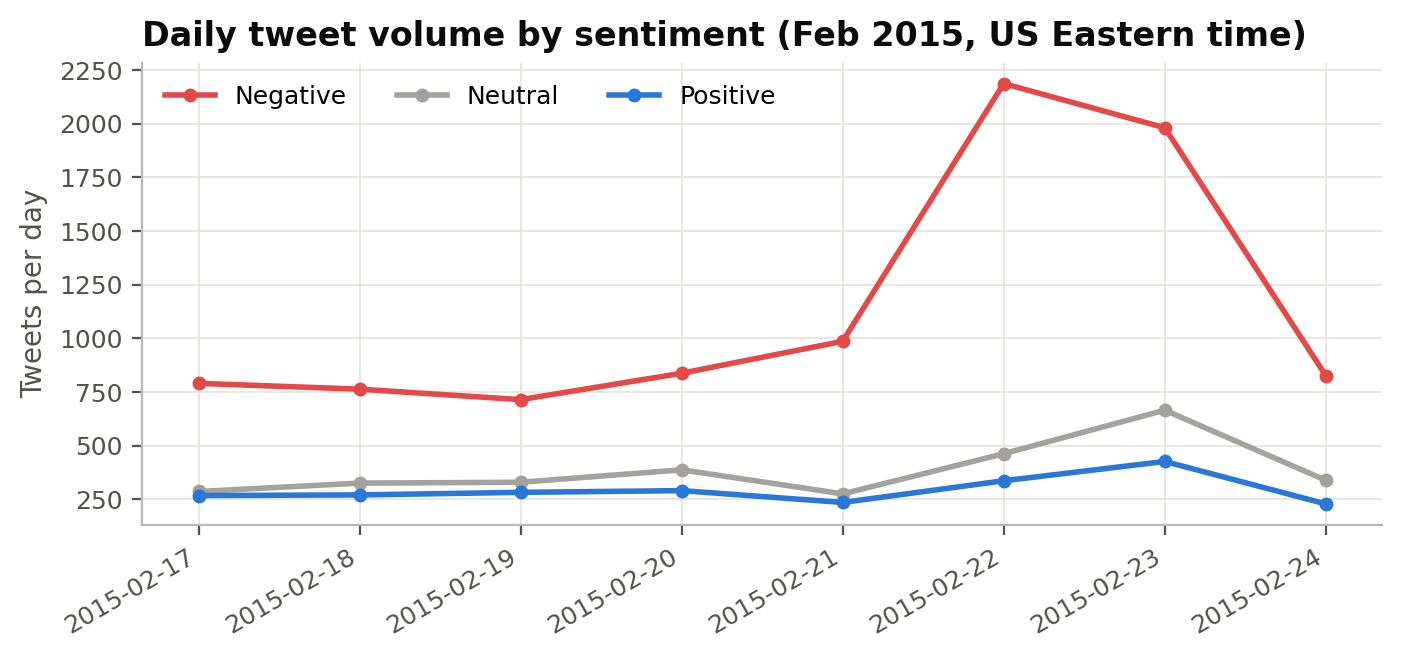

In [6]:
for name in ["sentiment_distribution", "sentiment_by_airline", "negative_reasons", "reasons_by_airline",
             "length_by_sentiment", "daily_volume"]:
    getattr(eda, f"fig_{name}")(df, FIG / f"eda_{name}.png")
    show(FIG / f"eda_{name}.png")

### 1.7 Interpretation of Exploratory Visualizations

- Read the airline sentiment proportions together with their tweet counts: a larger number of negative tweets can reflect higher sampled volume as well as a higher negative share.
- Reason-by-airline plots describe existing negative-tweet annotations. They can guide investigation of service themes, but do not show reasons inferred by the sentiment model.
- Daily-volume and tweet-length plots describe this short collection window. They cannot establish seasonality or show that tweet length causes sentiment.


### 1.8 Stratified Training, Validation, and Test Partitioning


In [7]:
splits = split_data(df)
pd.DataFrame({part: getattr(splits, part)["airline_sentiment"].value_counts(normalize=True).reindex(config.LABELS)
              for part in ("train", "val", "test")}).T.assign(
    n=[len(splits.train), len(splits.val), len(splits.test)]).round(3)

airline_sentiment,negative,neutral,positive,n
train,0.627,0.212,0.161,10139
val,0.627,0.212,0.161,2173
test,0.627,0.212,0.161,2173


### 1.9 Partition Balance and Potential Data Leakage

- The 10,139 training, 2,173 validation and 2,173 test tweets retain nearly identical sentiment proportions (62.7%, 21.2%, 16.1%). Stratification preserves minority-class representation for evaluation.
- Disjoint tweet IDs do not guarantee independent texts: the documented 13 overlapping lowercased texts between development and test sets remain a leakage concern. Grouped or chronological evaluation would provide a stronger check.


## 2. Text Preprocessing and Linguistic Normalization

The classical pipeline decodes HTML entities, removes URLs and user mentions, normalizes hashtags and repeated characters, expands contractions, and converts supported emoji and emoticons into tokens. It then tokenizes the text, applies part-of-speech-guided lemmatization, and removes punctuation, numbers, and stop words while retaining negation cues and selected intensifiers.

These steps reduce vocabulary variation and remove nonlinguistic content. Negation is retained because removing a word such as *not* can change the meaning of a phrase. The ablation study below evaluates whether the cleaning choices improve classification; a smaller vocabulary does not necessarily produce a better model. The BiLSTM retains stop words to preserve sequence context, while the optional Transformer receives lightly cleaned text.



### 2.1 Record-Level Illustration of Text Transformations


In [ ]:
# Use actual customer-feedback records; tweet IDs preserve traceability to Tweets.csv.
pp = TweetPreprocessor()
example_rows = df.sample(4, random_state=config.SEED)
examples = example_rows["text"].tolist()
pd.DataFrame({
    "tweet_id": example_rows["tweet_id"].tolist(),
    "original": examples,
    "normalised": [normalize_tweet(t) for t in examples],
    "final tokens": [pp.process(t) for t in examples],
    "Transformer input (light_clean)": [light_clean(t) for t in examples],
})


### 2.2 Corpus Preprocessing and Vocabulary Diagnostics


In [9]:
# Preprocess the whole corpus once (batched POS tagging) and index by tweet_id.
t0 = time.perf_counter()
all_tokens = pp.process_corpus(df["text"])
tokens_by_id = dict(zip(df["tweet_id"], all_tokens))
print(f"Preprocessed {len(all_tokens):,} tweets in {time.perf_counter() - t0:.0f}s")


def docs(part):
    # Space-joined preprocessed tokens for one split, in that split's row order.
    return [" ".join(tokens_by_id[i]) for i in getattr(splits, part)["tweet_id"]]


X_train, X_val, X_test = docs("train"), docs("val"), docs("test")
y_train, y_val, y_test = (getattr(splits, p)["label"].values for p in ("train", "val", "test"))

raw_vocab = len(set(df["text"].str.lower().str.split().explode()))
clean_vocab = len({t for toks in all_tokens for t in toks})
pd.DataFrame({"value": [df["text"].str.split().str.len().sum(), sum(map(len, all_tokens)), raw_vocab, clean_vocab,
                        sum(len(t) == 0 for t in all_tokens)]},
             index=["Raw whitespace tokens", "Tokens after preprocessing", "Raw vocabulary (lower-cased)",
                    "Vocabulary after preprocessing", "Tweets empty after preprocessing"])

Preprocessed 14,485 tweets in 11s


,value
Raw whitespace tokens,255803
Tokens after preprocessing,128920
Raw vocabulary (lower-cased),26840
Vocabulary after preprocessing,9040
Tweets empty after preprocessing,28


### 2.3 Information Retention and Preprocessing Constraints

- Preprocessing reduces whitespace-token counts from 255,803 to 128,920 and the lowercased vocabulary from 26,840 to 9,040. This compresses the representation, but performance must determine whether the removed information was useful.
- The preprocessing retains negation cues such as not, never and no, and converts supported emoji into tokens. The examples are actual dataset records identified by tweet ID. However, normalization and filtering can also discard information; inspect the original text alongside transformed examples.
- Twenty-eight tweets become empty after preprocessing. Such inputs contain no lexical evidence for downstream text features and deserve explicit monitoring.
- The saved execution includes failed NLTK resource-download messages despite producing processed output. Confirm the preprocessing resources and fallback behavior when reproducing the experiment.


### 2.4 Sentiment-Associated Lexical Patterns


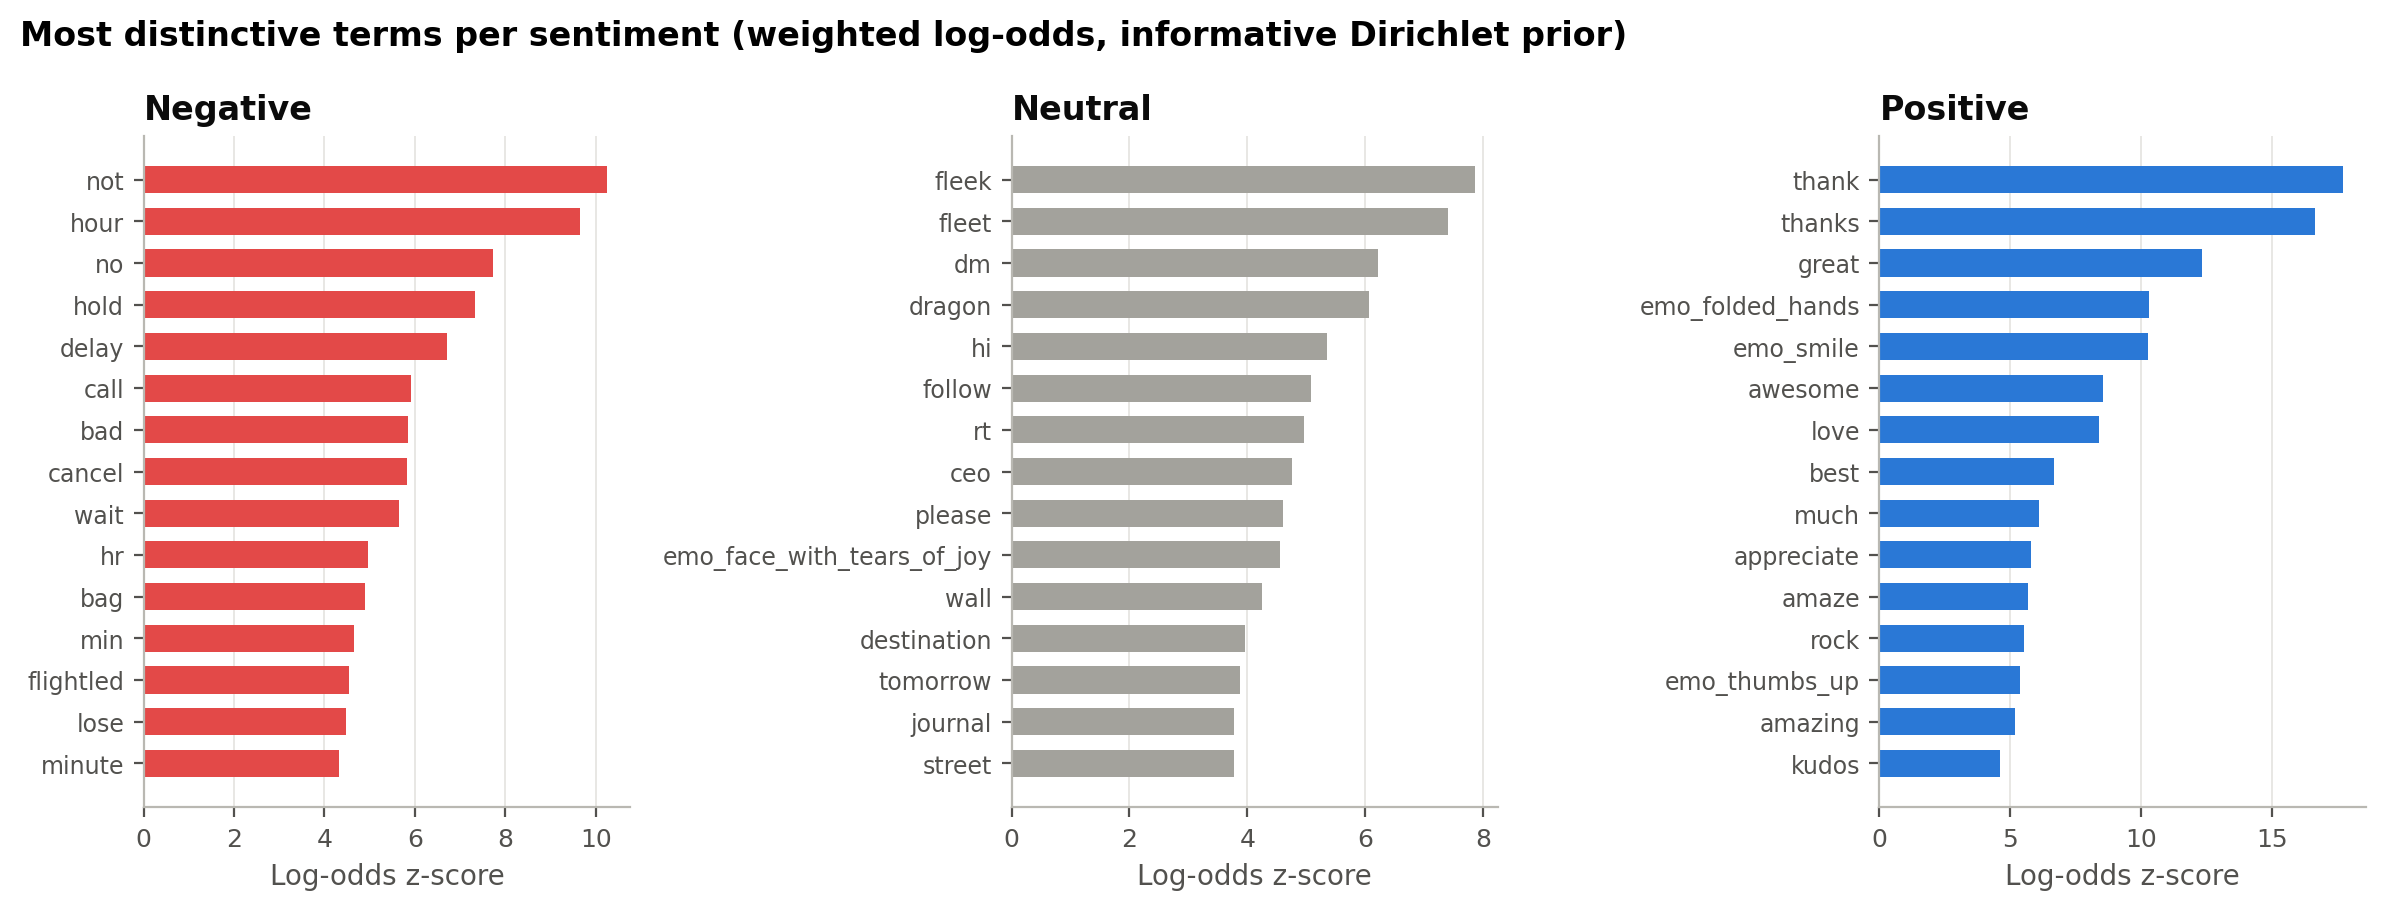

In [10]:
terms = eda.log_odds_dirichlet(all_tokens, df["label"].values)
eda.fig_distinctive_terms(terms, FIG / "eda_distinctive_terms.png")
show(FIG / "eda_distinctive_terms.png")

### 2.5 Interpretation of Sentiment-Associated Terms

- The displayed terms summarize associations with sentiment labels across the full corpus. Treat them as descriptive language patterns rather than causal explanations.
- Because this exploratory calculation uses all labels, including test labels, avoid using these terms to redesign features and then claiming an untouched test evaluation. Any data-driven feature selection should occur inside training folds.


### 2.6 Ablation Analysis of Preprocessing Components


In [11]:
ablation_path = MET / "preprocessing_ablation.csv"
if ablation_path.exists():
    ablation = pd.read_csv(ablation_path)
    display(ablation)
else:
    print("Run `python scripts/run_pipeline.py --stages ablation` to produce this table.")

,variant,cv_macro_f1_mean,cv_macro_f1_std,vocabulary_size
0,Raw text (lower-cased only),0.7462,0.0154,26445
1,"Normalised + tokenised (keep stop words, no lemmatisation)",0.7500,0.0088,23960
2,+ stop-word removal (negations kept),0.7347,0.0060,14572
3,+ lemmatisation (full pipeline – used),0.7319,0.0068,14416
4,Full pipeline but negations removed as stop words,0.7207,0.0032,13682
5,Lemmatisation without stop-word removal,0.7487,0.0125,22253


### 2.7 Comparative Findings from the Preprocessing Ablation

- Normalization and tokenization with stop words retained has the highest displayed CV macro-F1 (0.7500), compared with 0.7462 for lowercased raw text and 0.7319 for the full pipeline.
- Stop-word removal lowers the mean to 0.7347; adding lemmatization lowers it further to 0.7319. Smaller vocabulary therefore does not imply better classification in this experiment.
- Removing negations lowers the full-pipeline score to 0.7207, a further 0.0112 loss. Retaining negations is supported by this comparison, while the small differences between leading variants need paired fold-level analysis before claiming significance.


## 3. Text Representation and Feature Engineering

**TF-IDF** represents each tweet using weighted word frequencies. Unigrams capture individual terms, and bigrams capture short phrases. The combined word-and-character representation adds character sequences that may capture spelling variation. **Word2Vec** learns 100-dimensional word vectors; their IDF-weighted mean provides a dense representation of each tweet.

Predictive vocabulary, IDF weights, and embeddings are fitted within the training portion of each cross-validation fold. The standalone feature diagnostics below illustrate the representations; the fitted model pipelines determine the evaluation results.



### 3.1 TF-IDF Construction and Sparse-Matrix Diagnostics


In [12]:
tfidf = word_tfidf(ngram_range=(1, 2)).fit(X_train)
X_train_tfidf = tfidf.transform(X_train)
print(f"TF-IDF matrix: {X_train_tfidf.shape[0]:,} tweets × {X_train_tfidf.shape[1]:,} features; "
      f"density {X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.4%}")

idf = pd.Series(tfidf.idf_, index=tfidf.get_feature_names_out())
pd.DataFrame({"lowest IDF (most common)": idf.nsmallest(12).index,
              "highest IDF (rarest kept)": idf.nlargest(12).index})

TF-IDF matrix: 10,139 tweets × 11,994 features; density 0.0967%


,lowest IDF (most common),highest IDF (rarest kept)
0,flight,aa dfw
1,not,aa employee
2,get,aa family
3,no,aa gate
4,hour,aa mile
5,thanks,aa number
6,service,aa one
7,help,aa ref
8,cancel,aa take
9,customer,aa wait


### 3.2 Interpretation of TF-IDF Feature Characteristics

- The training matrix contains 11,994 features with only 0.0967% nonzero entries. Sparse storage is appropriate, and vocabulary fitting on training text avoids using test vocabulary in this diagnostic.
- Common terms include flight, service and delay, while not and no remain in the vocabulary. Rare retained bigrams may be specific to routes or individual interactions, so rarity alone is not evidence of predictive value.


### 3.3 Word2Vec Training and Semantic Similarity Analysis


In [13]:
# Word2Vec: nearest neighbours show that the embedding has learned domain semantics.
w2v = Word2VecVectorizer().fit(X_train)
probe = ["delay", "rude", "great", "bag", "refund"]
pd.DataFrame({w: [f"{n} ({s:.2f})" for n, s in w2v.model_.wv.most_similar(w, topn=6)] for w in probe if w in w2v.model_.wv})

,delay,rude,great,bag,refund
0,inbound (0.64),uncaring (0.68),amazing (0.54),checked (0.64),contd (0.63)
1,thirty (0.58),tisk (0.66),ricoh (0.49),snowboard (0.58),transferable (0.62)
2,shanghai (0.58),jacquie (0.64),achieve (0.49),luggage (0.58),exchange (0.61)
3,danger (0.58),plitt (0.64),fantastic (0.49),cvg (0.57),fund (0.61)
4,leaf (0.58),unhelpful (0.64),praise (0.48),apt (0.57),portion (0.60)
5,apparent (0.58),unprofessional (0.64),bright (0.47),bagage (0.57),hotline (0.59)


### 3.4 Embedding Quality and Representation Constraints

- Neighbors such as rude?uncaring, great?amazing and bag?luggage show useful domain associations. Other neighbors are less interpretable, indicating uneven embedding quality in this corpus.
- These examples assess local similarity, not classification accuracy. Averaging embeddings also compresses word order and local negation context; the later held-out model comparison is needed to assess usefulness.


### 3.5 Exploratory Projection of the Feature Space


C:\Users\alber\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alber\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alber\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alber\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", l

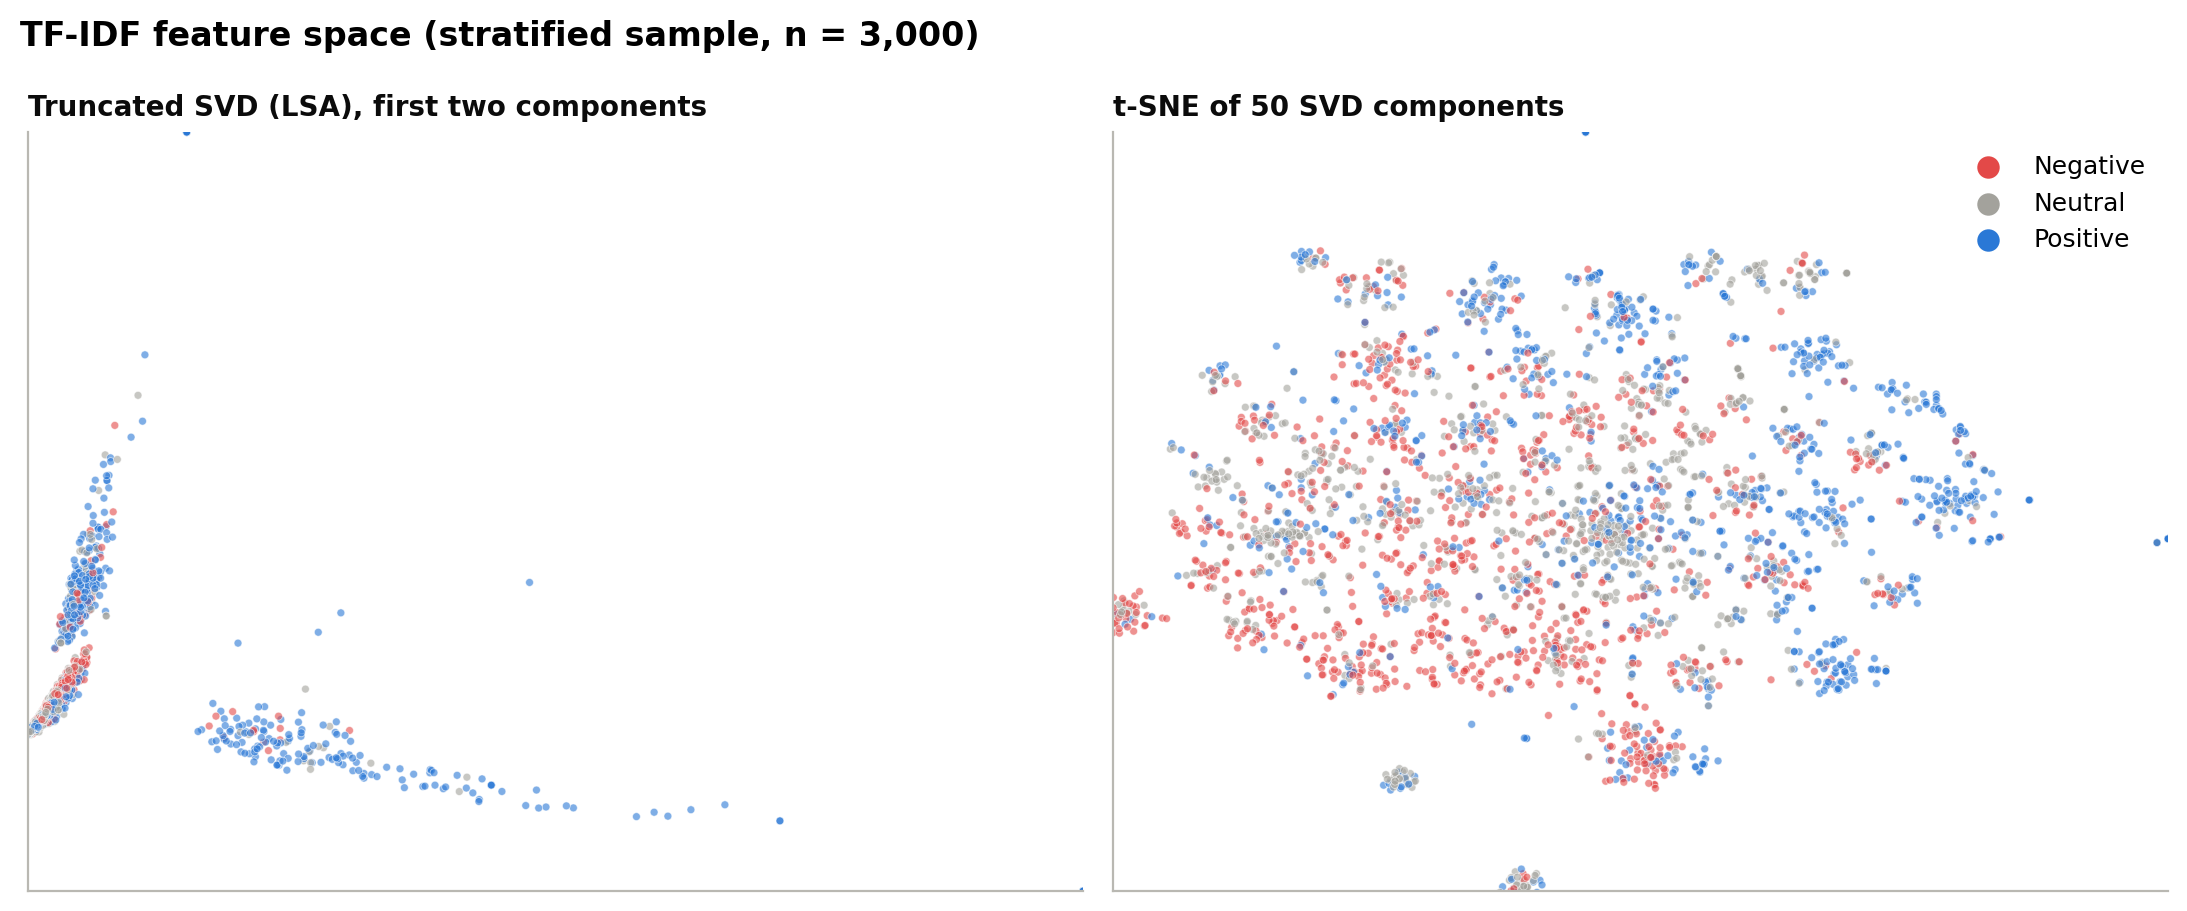

In [14]:
proj = project_feature_space(pd.Series(TweetPreprocessor.join(all_tokens)), df["label"])
eda.fig_feature_space(proj, FIG / "feature_space.png")
show(FIG / "feature_space.png")

### 3.6 Interpretation and Limitations of Feature-Space Projections

- A low-dimensional projection is an exploratory view of the representation. Apparent clusters or overlap do not substitute for held-out classification metrics because projection can distort distances.
- This visualization uses the corpus for exploration; keep any feature or model choices motivated by it within development-data validation.


## 4. Model Development and Training Protocols

Naive Bayes provides a simple probabilistic baseline. Logistic Regression offers interpretable coefficients, and Linear SVM is suitable for sparse text features. Comparing word-only and word-and-character SVM configurations evaluates the contribution of character features. Logistic Regression with Word2Vec tests a dense representation, while the BiLSTM evaluates a sequence model that can use word order.

Classical models use stratified five-fold cross-validation and macro-F1 for hyperparameter selection, then refit on the combined training and validation data. The BiLSTM trains on the training split and uses validation macro-F1 for checkpoint selection. The following cells document selected parameters and training settings. Transformer code is included as an optional extension, with no completed results claimed.


### 4.1 Classical Model Selection and Cross-Validation Strategy


In [15]:
specs = get_model_specs()
pd.DataFrame([{"slug": s.slug, "model": s.name, "features": s.features,
               "search grid": {k: v for k, v in s.param_grid.items()}} for s in specs])

,slug,model,features,search grid
0,nb_tfidf,Naive Bayes,TF-IDF (word n-grams),"{'tfidf__ngram_range': [(1, 1), (1, 2)], 'clf__alpha': [0.05, 0.1, 0.3, 0.5, 1.0], 'clf__fit_prior': [True, False]}"
1,lr_tfidf,Logistic Regression,TF-IDF (word n-grams),"{'tfidf__ngram_range': [(1, 1), (1, 2)], 'clf__C': [0.1, 0.25, 0.5, 1, 2, 5], 'clf__class_weight': [None, 'balanced']}"
2,svm_tfidf,Linear SVM,TF-IDF (word n-grams),"{'tfidf__ngram_range': [(1, 1), (1, 2)], 'clf__C': [0.05, 0.1, 0.25, 0.5, 1.0], 'clf__class_weight': [None, 'balance..."
3,svm_word_char,Linear SVM (word+char),TF-IDF (word 1-2 + char 2-5 n-grams),"{'clf__C': [0.01, 0.025, 0.05, 0.1, 0.25], 'clf__class_weight': [None, 'balanced']}"
4,lr_word2vec,Logistic Regression (Word2Vec),"Word2Vec skip-gram, 100-d, IDF-weighted mean","{'clf__C': [0.01, 0.1, 1.0], 'clf__class_weight': [None, 'balanced']}"


### 4.2 Classical Model Fitting and Held-Out Prediction


In [16]:
MODEL_INFO_DIR = MET / "models"
X_fit, y_fit = X_train + X_val, np.concatenate([y_train, y_val])

fitted, infos, preds = {}, {}, {}
for spec in specs:
    info_path = MODEL_INFO_DIR / f"{spec.slug}.json"
    t0 = time.perf_counter()
    if RUN_GRID_SEARCH or not info_path.exists():
        model, info = tune_and_fit(spec, X_fit, y_fit)
        mode = "grid search"
    else:
        # Refit with the hyper-parameters the grid search selected (JSON stores tuples as lists).
        info = json.loads(info_path.read_text())
        params = {k: tuple(v) if isinstance(v, list) else v for k, v in info["best_params"].items()}
        model = spec.build().set_params(**params).fit(X_fit, y_fit)
        mode = "refit with tuned params"
    y_pred = model.predict(X_test)
    preds[spec.slug] = pd.DataFrame({"tweet_id": splits.test["tweet_id"], "y_true": y_test, "y_pred": y_pred})
    preds[spec.slug][ev.SCORE_COLUMNS] = decision_scores(model, X_test)
    fitted[spec.slug], infos[spec.slug] = model, info
    print(f"{spec.name:<32s} {mode:<24s} {time.perf_counter() - t0:5.1f}s  params={info['best_params']}")

pd.DataFrame(infos).T[["name", "features", "best_params", "cv_macro_f1_mean", "cv_macro_f1_std"]]

Naive Bayes                      refit with tuned params    0.6s  params={'clf__alpha': 0.5, 'clf__fit_prior': False, 'tfidf__ngram_range': [1, 2]}


Logistic Regression              refit with tuned params    1.3s  params={'clf__C': 0.5, 'clf__class_weight': 'balanced', 'tfidf__ngram_range': [1, 2]}


Linear SVM                       refit with tuned params    1.0s  params={'clf__C': 0.25, 'clf__class_weight': 'balanced', 'tfidf__ngram_range': [1, 2]}


Linear SVM (word+char)           refit with tuned params    4.9s  params={'clf__C': 0.05, 'clf__class_weight': 'balanced'}


Logistic Regression (Word2Vec)   refit with tuned params   21.5s  params={'clf__C': 0.01, 'clf__class_weight': 'balanced'}


,name,features,best_params,cv_macro_f1_mean,cv_macro_f1_std
nb_tfidf,Naive Bayes,TF-IDF (word n-grams),"{'clf__alpha': 0.5, 'clf__fit_prior': False, 'tfidf__ngram_range': [1, 2]}",0.7012,0.005
lr_tfidf,Logistic Regression,TF-IDF (word n-grams),"{'clf__C': 0.5, 'clf__class_weight': 'balanced', 'tfidf__ngram_range': [1, 2]}",0.7285,0.0088
svm_tfidf,Linear SVM,TF-IDF (word n-grams),"{'clf__C': 0.25, 'clf__class_weight': 'balanced', 'tfidf__ngram_range': [1, 2]}",0.7338,0.0135
svm_word_char,Linear SVM (word+char),TF-IDF (word 1-2 + char 2-5 n-grams),"{'clf__C': 0.05, 'clf__class_weight': 'balanced'}",0.7417,0.0092
lr_word2vec,Logistic Regression (Word2Vec),"Word2Vec skip-gram, 100-d, IDF-weighted mean","{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.6646,0.0081


### 4.3 Prediction Integrity and Reproducibility Assessment


In [17]:
# Verify held-out IDs/labels before comparing notebook and saved predictions.
saved = ev.load_predictions()
ev.validate_predictions(preds, splits.test)
ev.validate_predictions(saved, splits.test)
for slug, p in preds.items():
    if slug in saved:
        agree = (saved[slug].set_index("tweet_id")["y_pred"].reindex(p["tweet_id"]).values == p["y_pred"].values).mean()
        print(f"{slug:<14s} agreement with saved predictions: {agree:.2%}")
        if agree < 1:
            warnings.warn(f"{slug}: refit differs from saved predictions; notebook results reflect this refit. Rebuild the paper after running the notebook.")


nb_tfidf       agreement with saved predictions: 100.00%
lr_tfidf       agreement with saved predictions: 100.00%
svm_tfidf      agreement with saved predictions: 100.00%
svm_word_char  agreement with saved predictions: 100.00%
lr_word2vec    agreement with saved predictions: 100.00%


### 4.4 Cross-Validation Findings and Training-Data Comparability

- The saved CV macro-F1 is highest for word+character SVM (0.7417), followed by word-only SVM (0.7338); Word2Vec Logistic Regression is lowest (0.6646). Character features are a promising candidate, with their held-out benefit assessed below.
- All five refitted classical models reproduce the saved predicted labels exactly in this execution. Label agreement supports consistency of this run, but does not establish identical scores or complete reconstruction of the historical searches.
- Classical models refit on training plus validation data (85% of the corpus). Neural models use 70% for training and 15% for checkpoint selection, which limits a controlled comparison of algorithms.


### 4.5 Bidirectional Long Short-Term Memory (BiLSTM) Model


In [18]:
from src.rnn_model import RNNConfig
display(pd.Series(vars(RNNConfig()), name="BiLSTM hyper-parameters").astype(str).to_frame())

if TRAIN_BILSTM:
    import torch
    from src.rnn_model import predict_proba as rnn_proba, train_bilstm
    seq_pp = TweetPreprocessor(remove_stopwords=False)
    seq = {p: seq_pp.process_corpus(getattr(splits, p)["text"]) for p in ("train", "val", "test")}
    rnn, vocab, rnn_info = train_bilstm(seq["train"], y_train, seq["val"], y_val, RNNConfig())
    probs = rnn_proba(rnn, vocab, seq["test"], RNNConfig().max_len)
    rnn_info.update({"slug": "bilstm", "name": "BiLSTM (RNN)", "family": "Deep learning (RNN)"})
    MODEL_INFO_DIR.mkdir(parents=True, exist_ok=True)
    (MODEL_INFO_DIR / "bilstm.json").write_text(json.dumps(rnn_info, indent=2), encoding="utf-8")
    ev.save_predictions("bilstm", splits.test["tweet_id"], y_test, probs.argmax(1), probs)
    ev.plot_training_history(rnn_info["history"], "BiLSTM training curves", FIG / "training_bilstm.png")

,BiLSTM hyper-parameters
embedding_dim,100
hidden_dim,128
dropout,0.4
max_len,40
min_freq,2
batch_size,64
lr,0.001
max_epochs,15
patience,3
class_weighted,True


### 4.6 Optional Transformer Extension: DistilRoBERTa Fine-Tuning


In [19]:
from src.transformer_model import TransformerConfig
display(pd.Series(vars(TransformerConfig()), name="DistilRoBERTa hyper-parameters").astype(str).to_frame())

if TRAIN_TRANSFORMER:
    from src.transformer_model import predict_proba as tr_proba, train_transformer
    cfg = TransformerConfig()
    clean = {p: [light_clean(t) for t in getattr(splits, p)["text"]] for p in ("train", "val", "test")}
    tr_model, tokenizer, tr_info = train_transformer(clean["train"], y_train, clean["val"], y_val, cfg,
                                                     save_dir=config.MODELS_DIR / "distilroberta")
    probs = tr_proba(tr_model, tokenizer, clean["test"], cfg.max_length)
    tr_info.update({"slug": "distilroberta", "name": "DistilRoBERTa", "family": "Deep learning (Transformer)"})
    MODEL_INFO_DIR.mkdir(parents=True, exist_ok=True)
    (MODEL_INFO_DIR / "distilroberta.json").write_text(json.dumps(tr_info, indent=2), encoding="utf-8")
    ev.save_predictions("distilroberta", splits.test["tweet_id"], y_test, probs.argmax(1), probs)
    ev.plot_training_history(tr_info["history"], "DistilRoBERTa fine-tuning curves", FIG / "training_distilroberta.png")

,DistilRoBERTa hyper-parameters
model_name,distilroberta-base
max_length,64
batch_size,32
lr,2e-05
weight_decay,0.01
epochs,3
warmup_ratio,0.1
seed,42


### 4.7 Neural Prediction Artifacts and Experiment Metadata


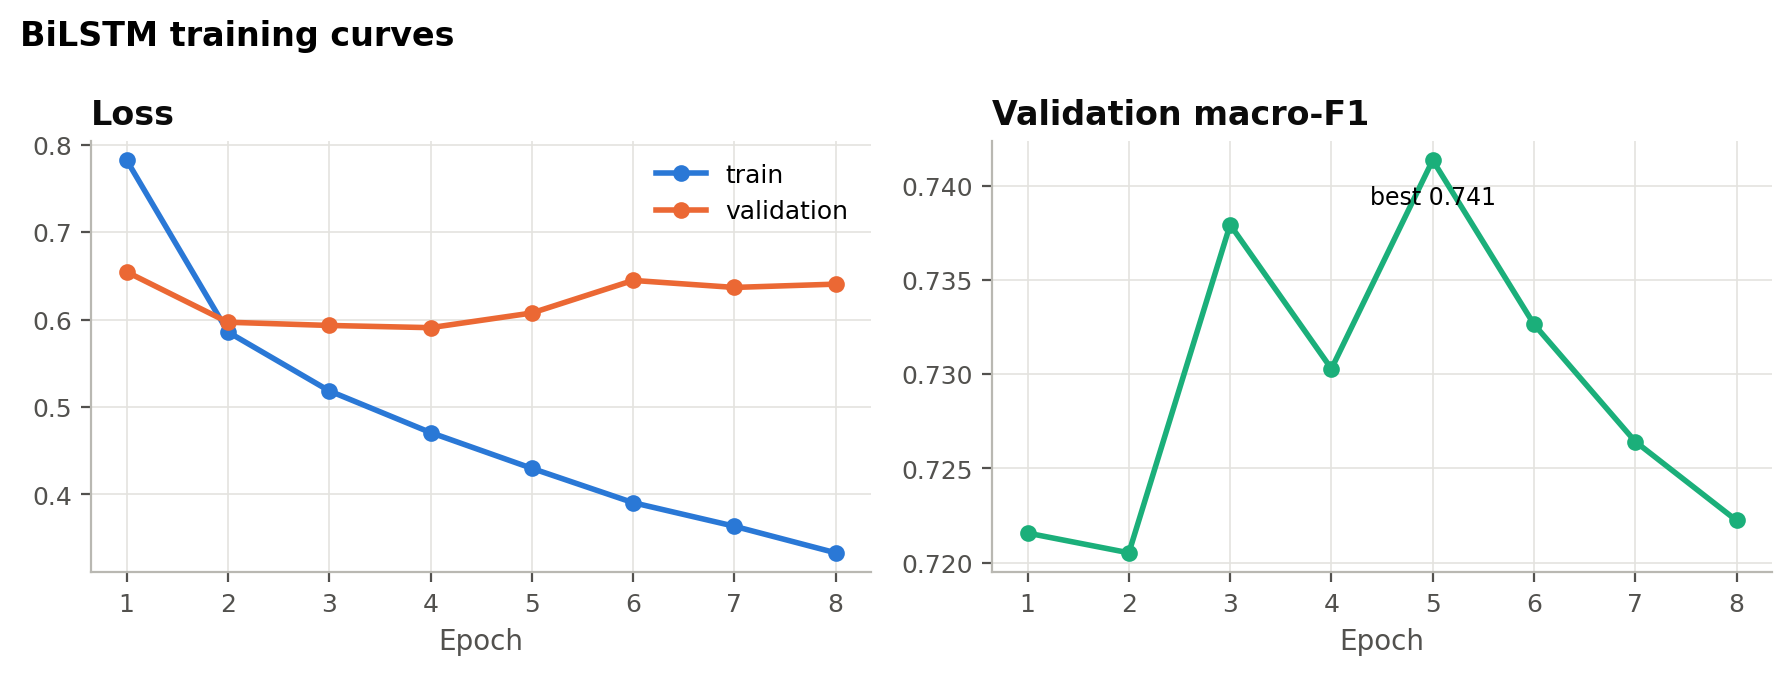

distilroberta: no saved predictions yet. Run `python scripts/run_pipeline.py --stages transformer` or set the TRAIN flag above.
Models in the comparison: ['Naive Bayes', 'Logistic Regression', 'Linear SVM', 'Linear SVM (word+char)', 'Logistic Regression (Word2Vec)', 'BiLSTM (RNN)']


In [20]:
# Add the neural models' saved test predictions (same test tweets, same CSV schema).
for slug in ("bilstm", "distilroberta"):
    pred_path = config.PREDICTIONS_DIR / f"{slug}_test.csv"
    info_path = MODEL_INFO_DIR / f"{slug}.json"
    if pred_path.exists():
        preds[slug] = pd.read_csv(pred_path)
        infos[slug] = json.loads(info_path.read_text()) if info_path.exists() else {"name": slug}
        fig_path = FIG / f"training_{slug}.png"
        if fig_path.exists():
            show(fig_path, width=640)
    else:
        print(f"{slug}: no saved predictions yet. Run `python scripts/run_pipeline.py --stages "
              f"{'rnn' if slug == 'bilstm' else 'transformer'}` or set the TRAIN flag above.")

names = {slug: info.get("name", slug) for slug, info in infos.items()}
order = [m for m in MODEL_ORDER if m in preds]
print("Models in the comparison:", [names[m] for m in order])

### 4.8 Availability and Scope of Neural Model Evidence

- The comparison includes saved BiLSTM predictions, while the default switch leaves fresh BiLSTM training disabled. Interpret its results as evaluation of the saved experiment.
- DistilRoBERTa has no saved predictions in this execution. Its configuration and optional training code are not experimental evidence, and no Transformer performance ranking can be reported.


## 5. Predictive Performance and Statistical Evaluation

Accuracy measures the proportion of correct predictions. Precision measures how often predictions for a class are correct; recall measures how many actual examples of that class are identified. F1 combines precision and recall. Macro-averaged metrics weight each sentiment class equally and are particularly useful for this imbalanced dataset.

All evaluated models use the same 2,173 test tweets. Per-class reports and confusion matrices reveal errors hidden by overall accuracy. ROC curves assess ranking performance across thresholds, bootstrap intervals summarize sampling uncertainty, and paired McNemar tests assess differences in error rates. Model ranking and test-selected business thresholds remain exploratory.



### 5.1 Comparative Performance Metrics and Result Export


In [21]:
ev.validate_predictions(preds, splits.test)
table = ev.comparison_table(preds, names)
for col in ("family", "algorithm", "features", "cv_macro_f1_mean", "best_val_macro_f1", "inference_ms_per_1k"):
    table[col] = table["slug"].map(lambda s, c=col: infos.get(s, {}).get(c))
table.to_csv(MET / "model_comparison.csv", index=False)
best = table.iloc[0]["slug"]
cols = ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_macro_ci_low", "f1_macro_ci_high",
        "f1_weighted", "roc_auc_macro_ovr"]
display(Markdown(f"**Best model by macro-F1: {names[best]}**"))
table[cols].style.format(precision=3).highlight_max(subset=cols[1:], color="#d6e6fa")

**Best model by macro-F1: Linear SVM (word+char)**

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_ci_low,f1_macro_ci_high,f1_weighted,roc_auc_macro_ovr
0,Linear SVM (word+char),0.814,0.769,0.763,0.766,0.746,0.785,0.813,0.912
1,BiLSTM (RNN),0.797,0.746,0.786,0.762,0.741,0.781,0.803,0.920
2,Linear SVM,0.803,0.757,0.746,0.751,0.730,0.772,0.801,0.907
3,Logistic Regression,0.784,0.731,0.762,0.744,0.724,0.764,0.789,0.909
4,Naive Bayes,0.788,0.734,0.713,0.722,0.700,0.743,0.783,0.897
5,Logistic Regression (Word2Vec),0.720,0.658,0.692,0.670,0.648,0.692,0.730,0.863


### 5.2 Visualization of Comparative Model Performance


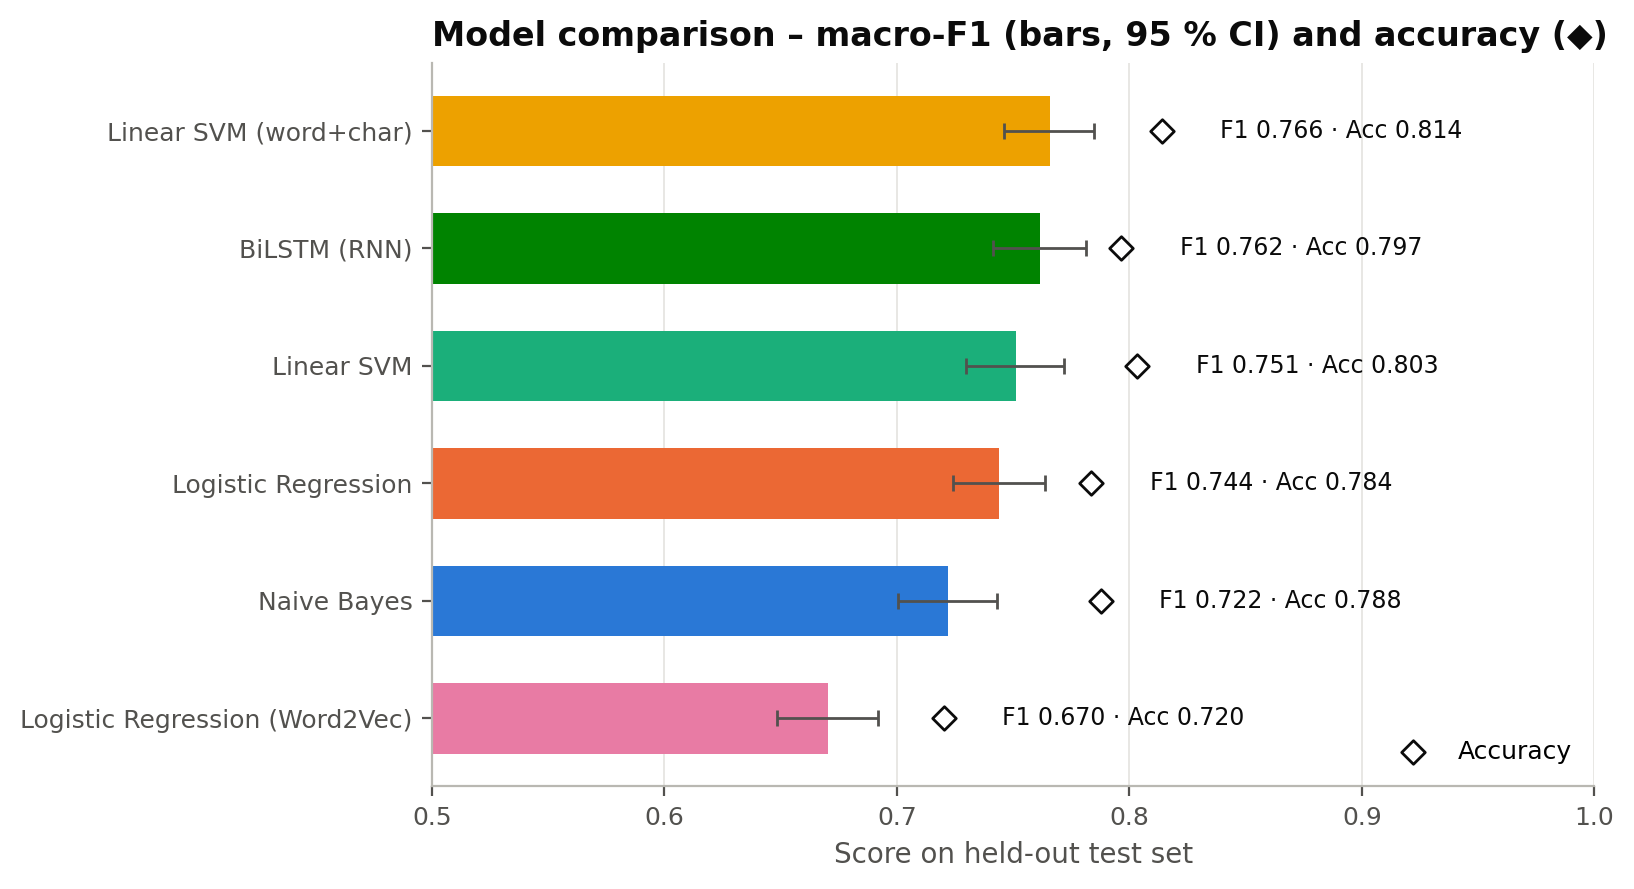

In [22]:
ev.plot_model_comparison(table, FIG / "model_comparison.png")
show(FIG / "model_comparison.png")

### 5.3 Overall Performance Findings and Model Ranking

- In the verified saved experiment, word+character SVM leads with 81.41% accuracy and macro-F1 0.7658, compared with BiLSTM macro-F1 0.7616. The macro-F1 gap is only 0.0042 and should be interpreted with uncertainty and the training-budget differences.
- Word2Vec Logistic Regression achieves macro-F1 0.6704. More complex or denser representations do not automatically improve this task; the observed ranking supports the TF-IDF SVM as a practical baseline.
- These values describe the saved experiment. If predictions change on rerun, use the newly generated comparison table and confidence intervals.


### 5.4 Class-Specific Precision, Recall, and F1-Score


precision  recall     f1  support
model                          class                                      
Naive Bayes                    negative      0.845   0.893  0.868     1363
                               neutral       0.628   0.535  0.577      460
                               positive      0.730   0.711  0.721      350
Logistic Regression            negative      0.891   0.817  0.852     1363
                               neutral       0.581   0.687  0.629      460
                               positive      0.721   0.783  0.751      350
Linear SVM                     negative      0.859   0.885  0.872     1363
                               neutral       0.661   0.607  0.633      460
                               positive      0.752   0.746  0.749      350
Linear SVM (word+char)         negative      0.871   0.886  0.878     1363
                               neutral       0.681   0.641  0.661      460
                               positive      0.754   0.763  0.759      350
Logistic Regression (Word2Vec) negative      0.872   0.761  0.813     1363
                               neutral       0.478   0.615  0.538      460
                               positive      0.625   0.700  0.660      350
BiLSTM (RNN)                   negative      0.915   0.812  0.860     1363
                               neutral       0.595   0.754  0.665      460
                               positive      0.729   0.791  0.759      350

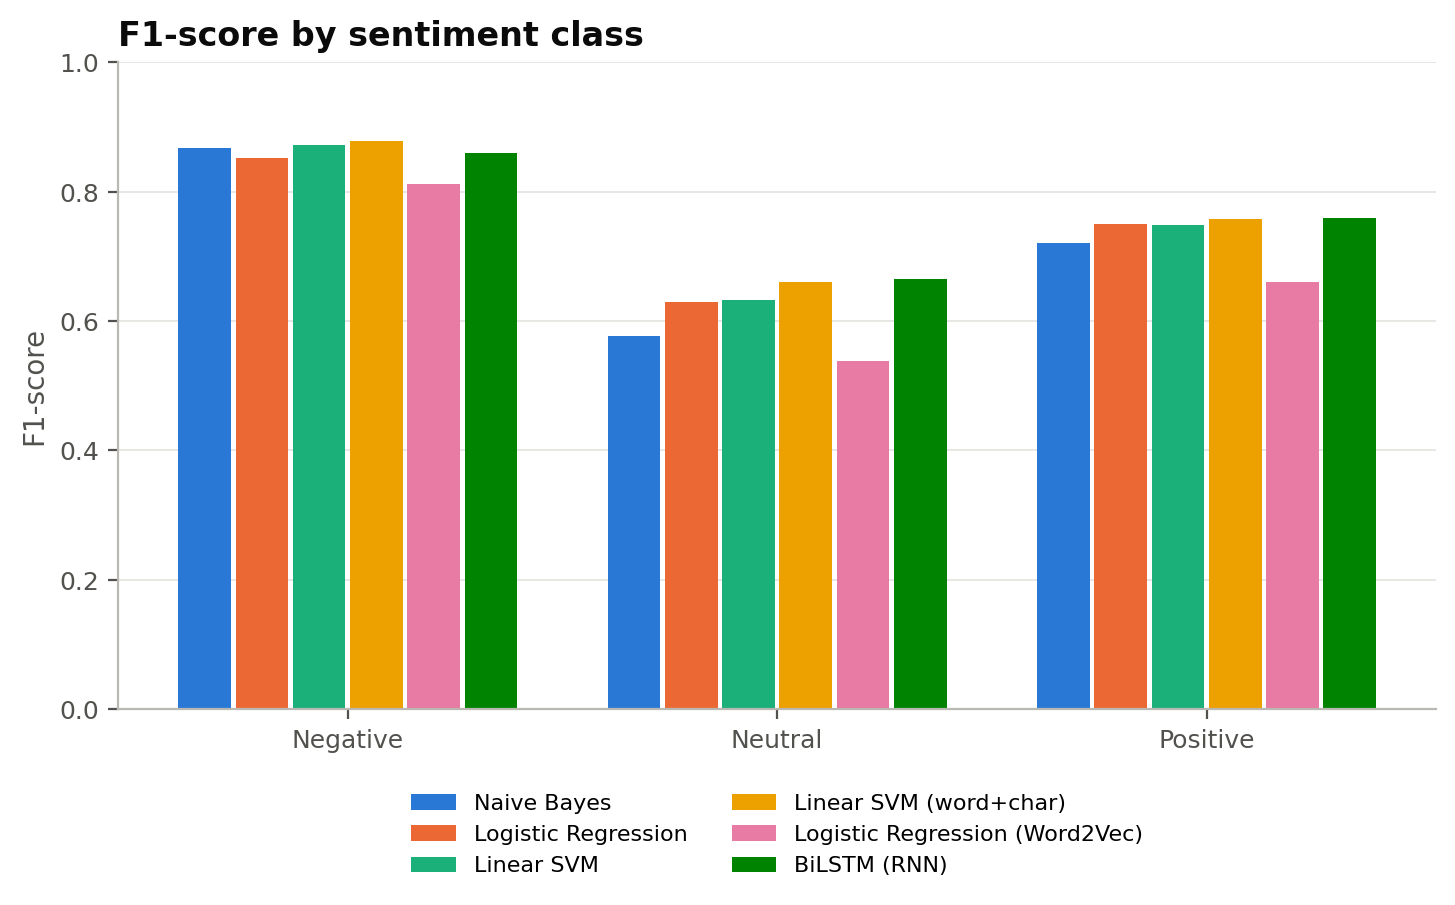

In [23]:
per_class = pd.concat({names[s]: ev.per_class_report(preds[s]["y_true"], preds[s]["y_pred"]) for s in order},
                      names=["model", "class"])
per_class.to_csv(MET / "per_class_metrics.csv")
display(per_class.round(3))
ev.plot_per_class_f1(preds, names, FIG / "per_class_f1.png", order)
show(FIG / "per_class_f1.png")

### 5.5 Class-Specific Findings and Error Tradeoffs

- For word+character SVM, negative F1 is 0.8781, positive F1 is 0.7585 and neutral F1 is 0.6607. Overall accuracy conceals the substantially weaker neutral-class performance.
- BiLSTM has higher neutral recall (0.754 versus 0.641) but lower neutral precision (0.595 versus 0.681). Its slightly higher neutral F1 reflects a different error tradeoff rather than improvement on every metric.


### 5.6 Row-Normalized Confusion Matrix Analysis


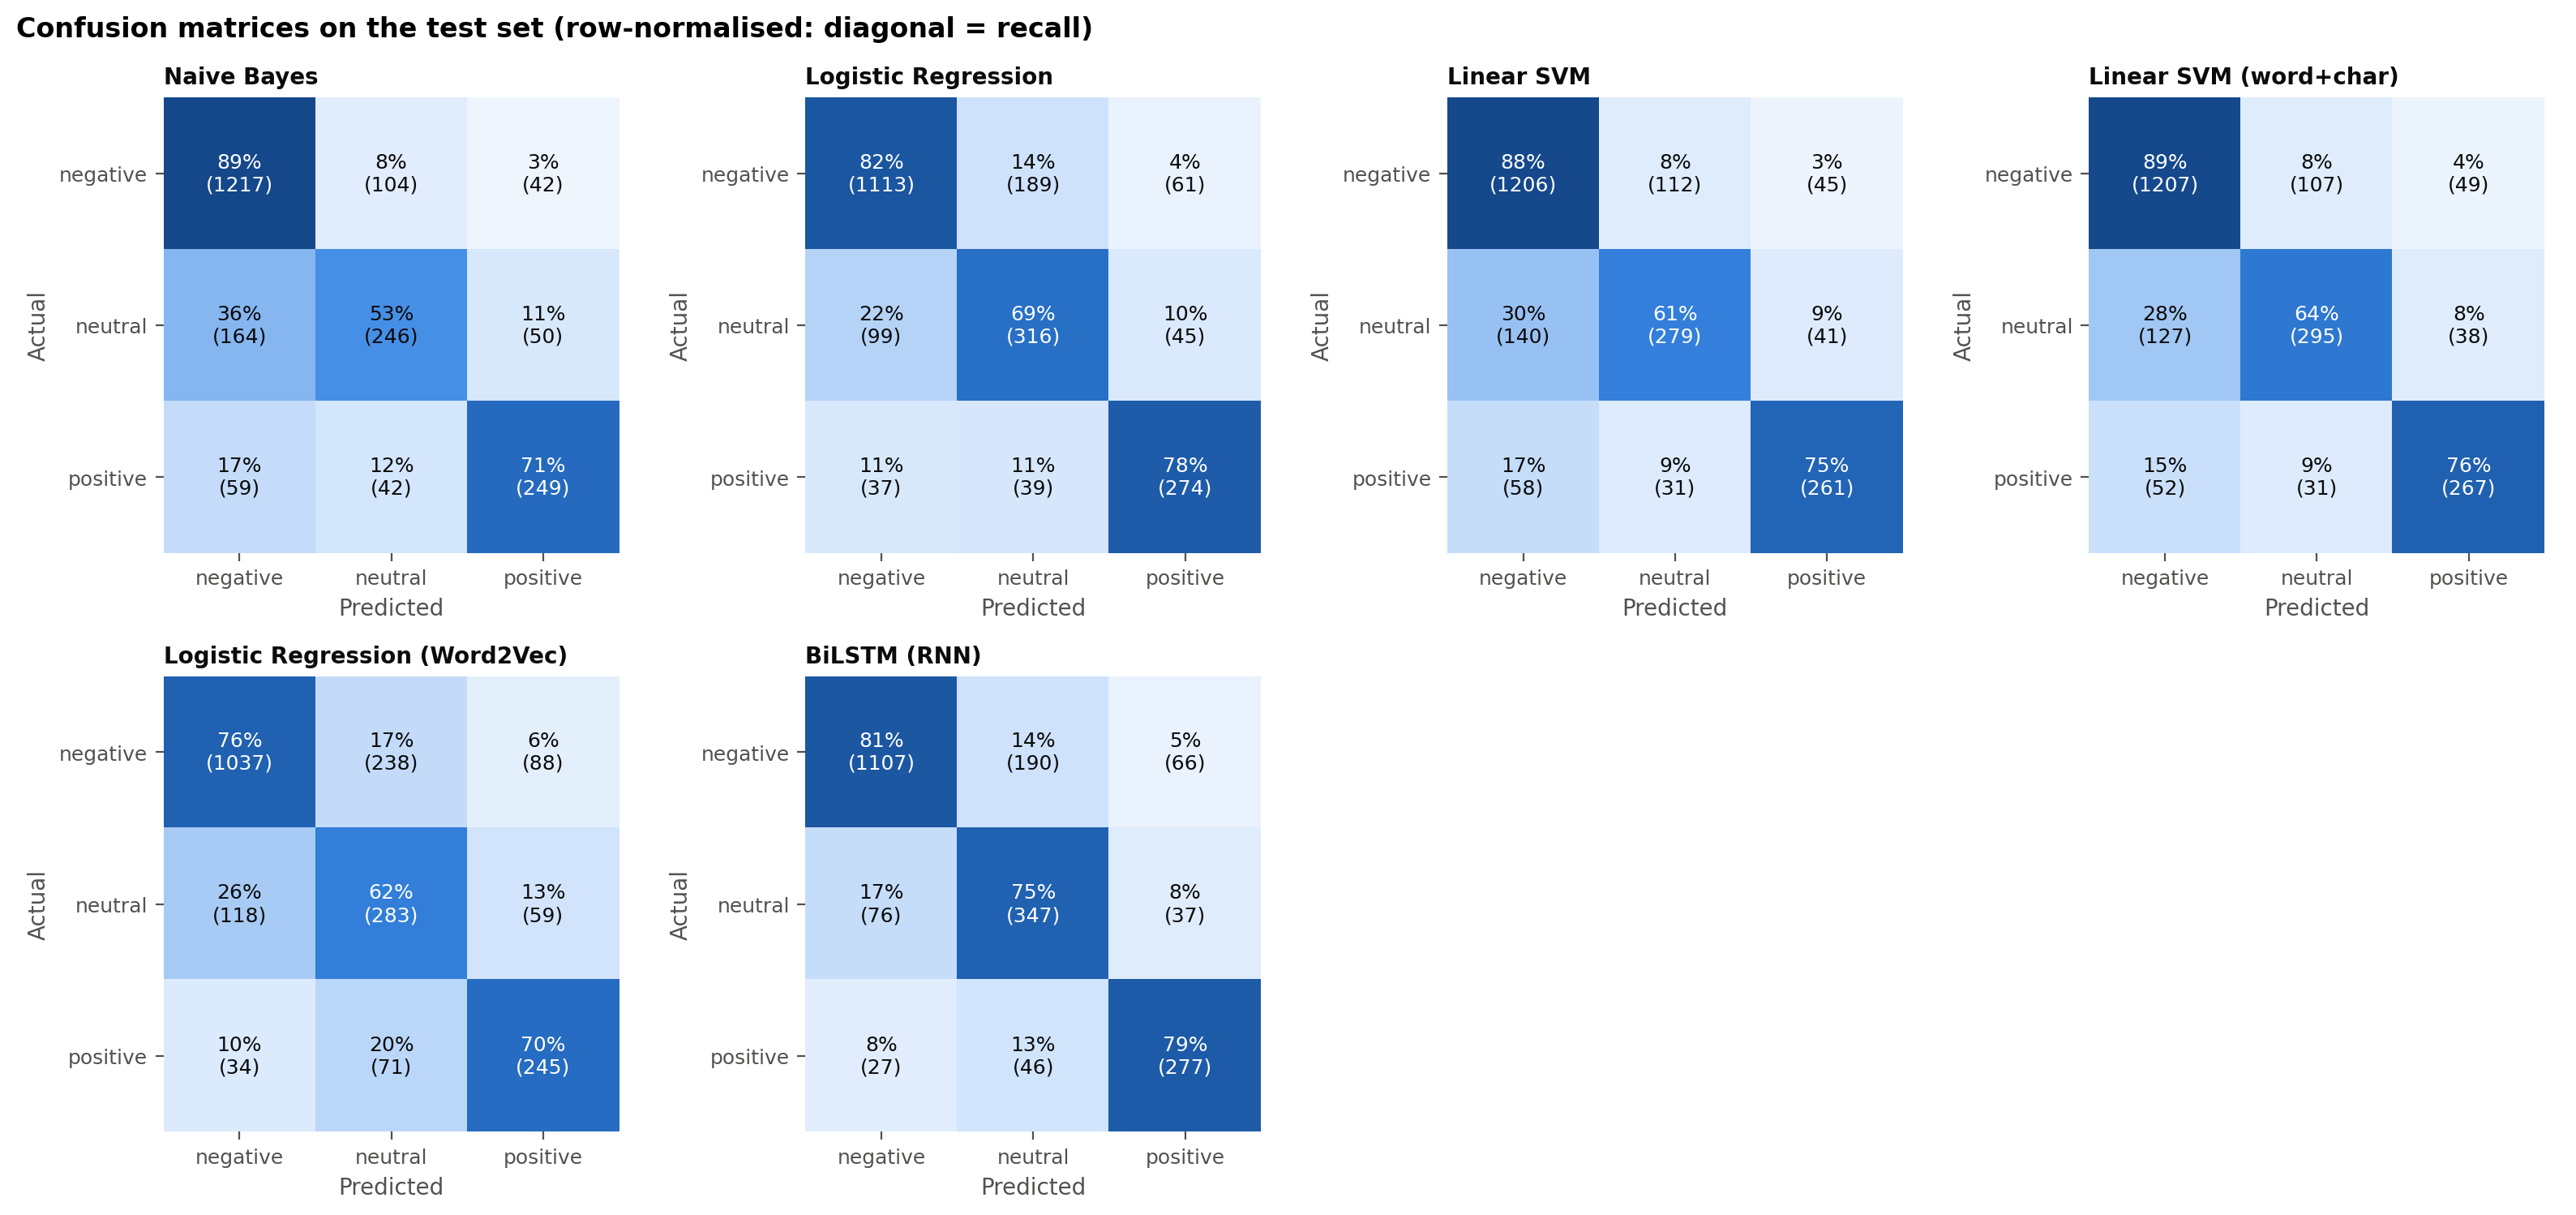

In [24]:
ev.plot_confusion_grid(preds, names, FIG / "confusion_matrices.png", order)
show(FIG / "confusion_matrices.png", width=900)

### 5.7 Interpretation of Class-Conditional Error Patterns

- For the leading SVM, approximately 11.4% of true negatives, 35.9% of true neutrals and 23.7% of true positives are misclassified, as implied by the displayed class recalls. Neutral tweets are the main class-level weakness.
- Row normalization compares error proportions within each true class. Use the support counts alongside these plots when assessing workload, because the classes have different numbers of tweets.


### 5.8 One-versus-Rest Receiver Operating Characteristic Analysis


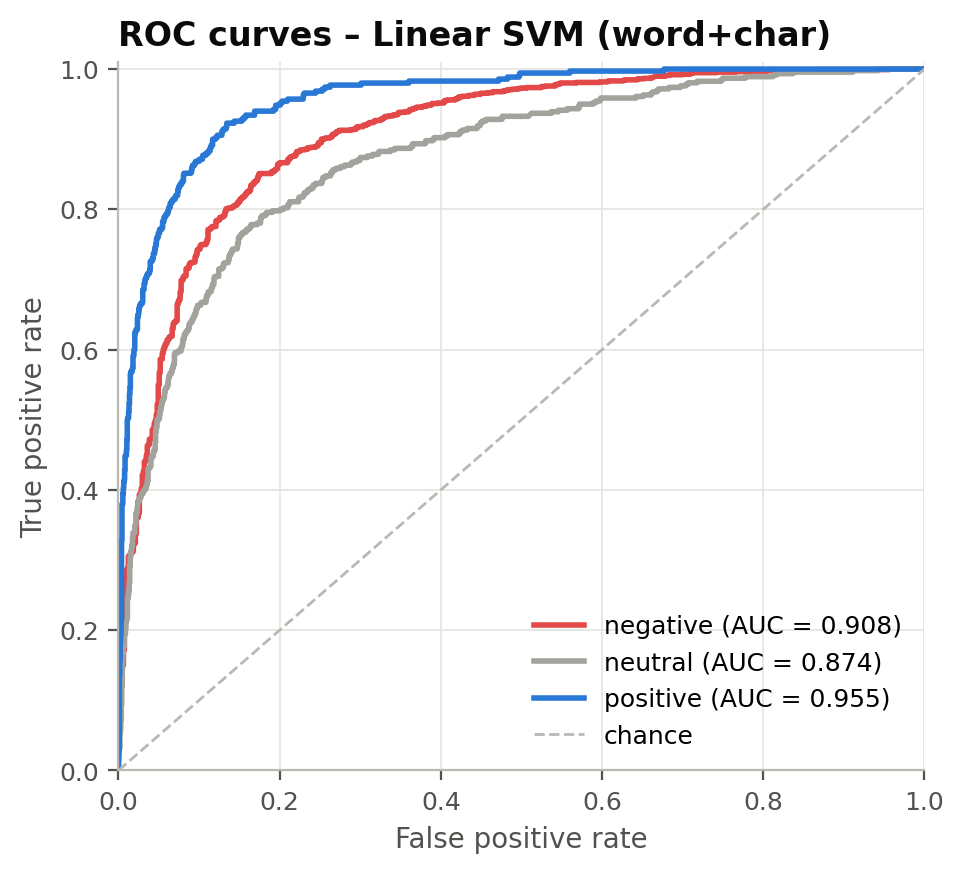

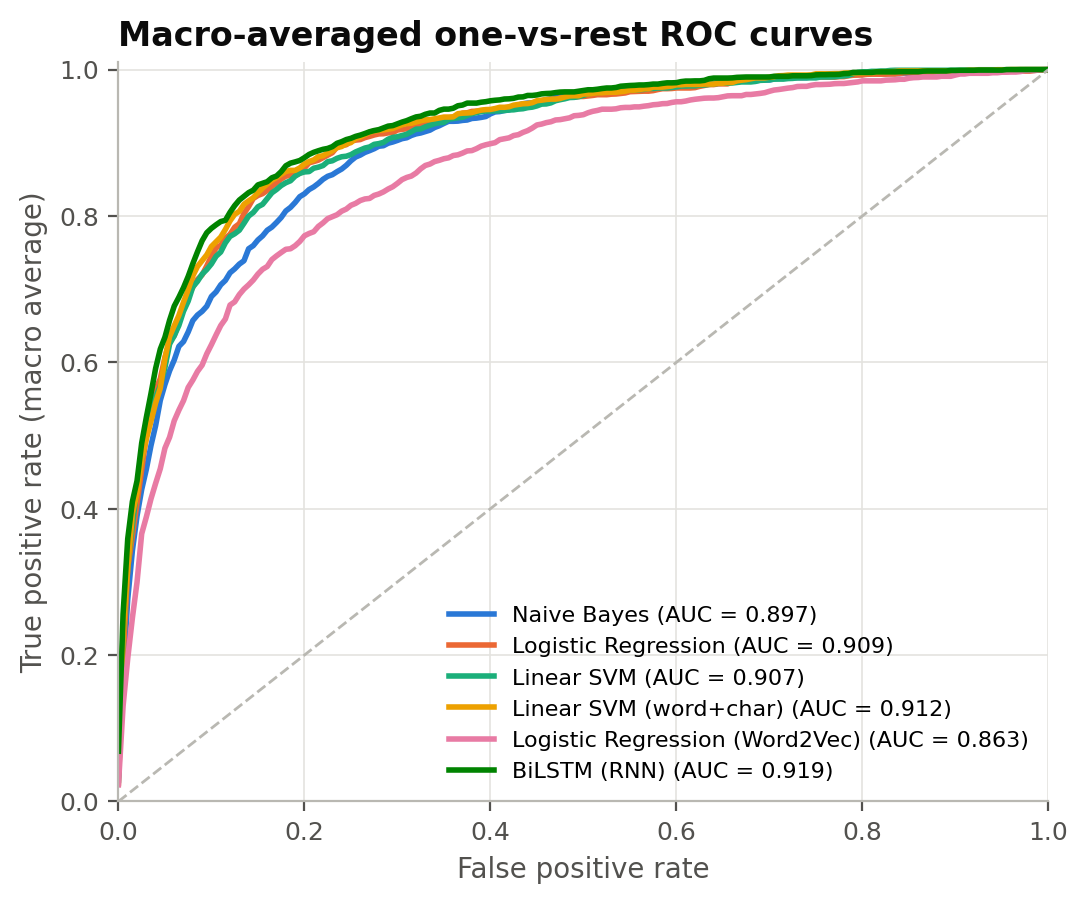

In [25]:
ev.plot_roc_per_class(preds[best], f"ROC curves – {names[best]}", FIG / "roc_best_model.png")
ev.plot_roc_by_model(preds, names, FIG / "roc_all_models.png", order)
show(FIG / "roc_best_model.png", width=560)
show(FIG / "roc_all_models.png", width=560)

### 5.9 Ranking Performance and Decision-Score Interpretation

- One-versus-rest ROC curves evaluate ranking over varying thresholds, while the class reports evaluate the chosen classification rule. A favorable ROC curve can coexist with weak neutral F1.
- SVM decision scores are margins rather than calibrated probabilities. For complaint triage, assess precision?recall and flagged workload at a validation-selected threshold as well as ROC-AUC.


### 5.10 Paired Error-Rate Comparisons Using McNemar?s Test


In [26]:
sig = ev.significance_table(preds, best, names)
sig.to_csv(MET / "mcnemar_tests.csv", index=False)
sig

,comparison,a_only_correct,b_only_correct,statistic,p_value,significant_at_0.05,p_value_holm,significant_holm_at_0.05
0,Linear SVM (word+char) vs Logistic Regression (Word2Vec),308,104,100.0218,1.5073e-23,True,7.5363e-23,True
1,Linear SVM (word+char) vs Logistic Regression,113,47,26.4062,2.7664e-07,True,1.1066e-06,True
2,Linear SVM (word+char) vs Naive Bayes,164,107,11.5720,6.6954e-04,True,2.0086e-03,True
3,Linear SVM (word+char) vs BiLSTM (RNN),152,114,5.1466,2.3292e-02,True,4.6583e-02,True
4,Linear SVM (word+char) vs Linear SVM,79,56,3.5852,5.8297e-02,False,5.8297e-02,False


### 5.11 Statistical Comparison Findings and Inferential Constraints

- Holm-adjusted McNemar tests detect an error-rate difference between word+character SVM and BiLSTM (p = 0.0466), but not word-only SVM (p = 0.0583). Failure to detect a difference does not establish equivalence.
- The comparison with BiLSTM has 152 tweets correct only for SVM and 114 correct only for BiLSTM. The paired test concerns correct versus incorrect predictions, not a direct test of the macro-F1 gap.
- Because the reference model is selected from this test-set comparison, treat these significance results as exploratory and confirm the choice on independent data.


### 5.12 Synthesis of Model Evaluation Findings


In [27]:
# Plain-language summary generated from the numbers above.
b = table.iloc[0]
lines = [f"* **{b['model']}** achieves macro-F1 **{b['f1_macro']:.3f}** "
         f"(95 % CI {b['f1_macro_ci_low']:.3f}–{b['f1_macro_ci_high']:.3f}) and accuracy **{b['accuracy']:.3f}**."]
classical = table[table["slug"].isin([s.slug for s in specs])]
if not classical.empty:
    c = classical.iloc[0]
    lines.append(f"* Best classical model: **{c['model']}**, macro-F1 {c['f1_macro']:.3f}.")
not_sig = sig.loc[~sig["significant_holm_at_0.05"], "comparison"].str.split(" vs ").str[1].tolist()
lines.append("* No detected paired error-rate difference after Holm adjustment (p ≥ 0.05): "
             + (", ".join(not_sig) if not_sig else "none; adjusted tests detect differences for every comparison") + ".")
weakest = per_class.xs(names[best], level="model")["f1"].idxmin()
lines.append(f"* Hardest class for the best model: **{weakest}** "
             f"(F1 {per_class.loc[(names[best], weakest), 'f1']:.3f}).")
display(Markdown("\n".join(lines)))

* **Linear SVM (word+char)** achieves macro-F1 **0.766** (95 % CI 0.746–0.785) and accuracy **0.814**.
* Best classical model: **Linear SVM (word+char)**, macro-F1 0.766.
* No detected paired error-rate difference after Holm adjustment (p ≥ 0.05): Linear SVM.
* Hardest class for the best model: **neutral** (F1 0.661).

## 6. Model Interpretation and Operational Implications


### 6.1 Logistic Regression Coefficient Analysis


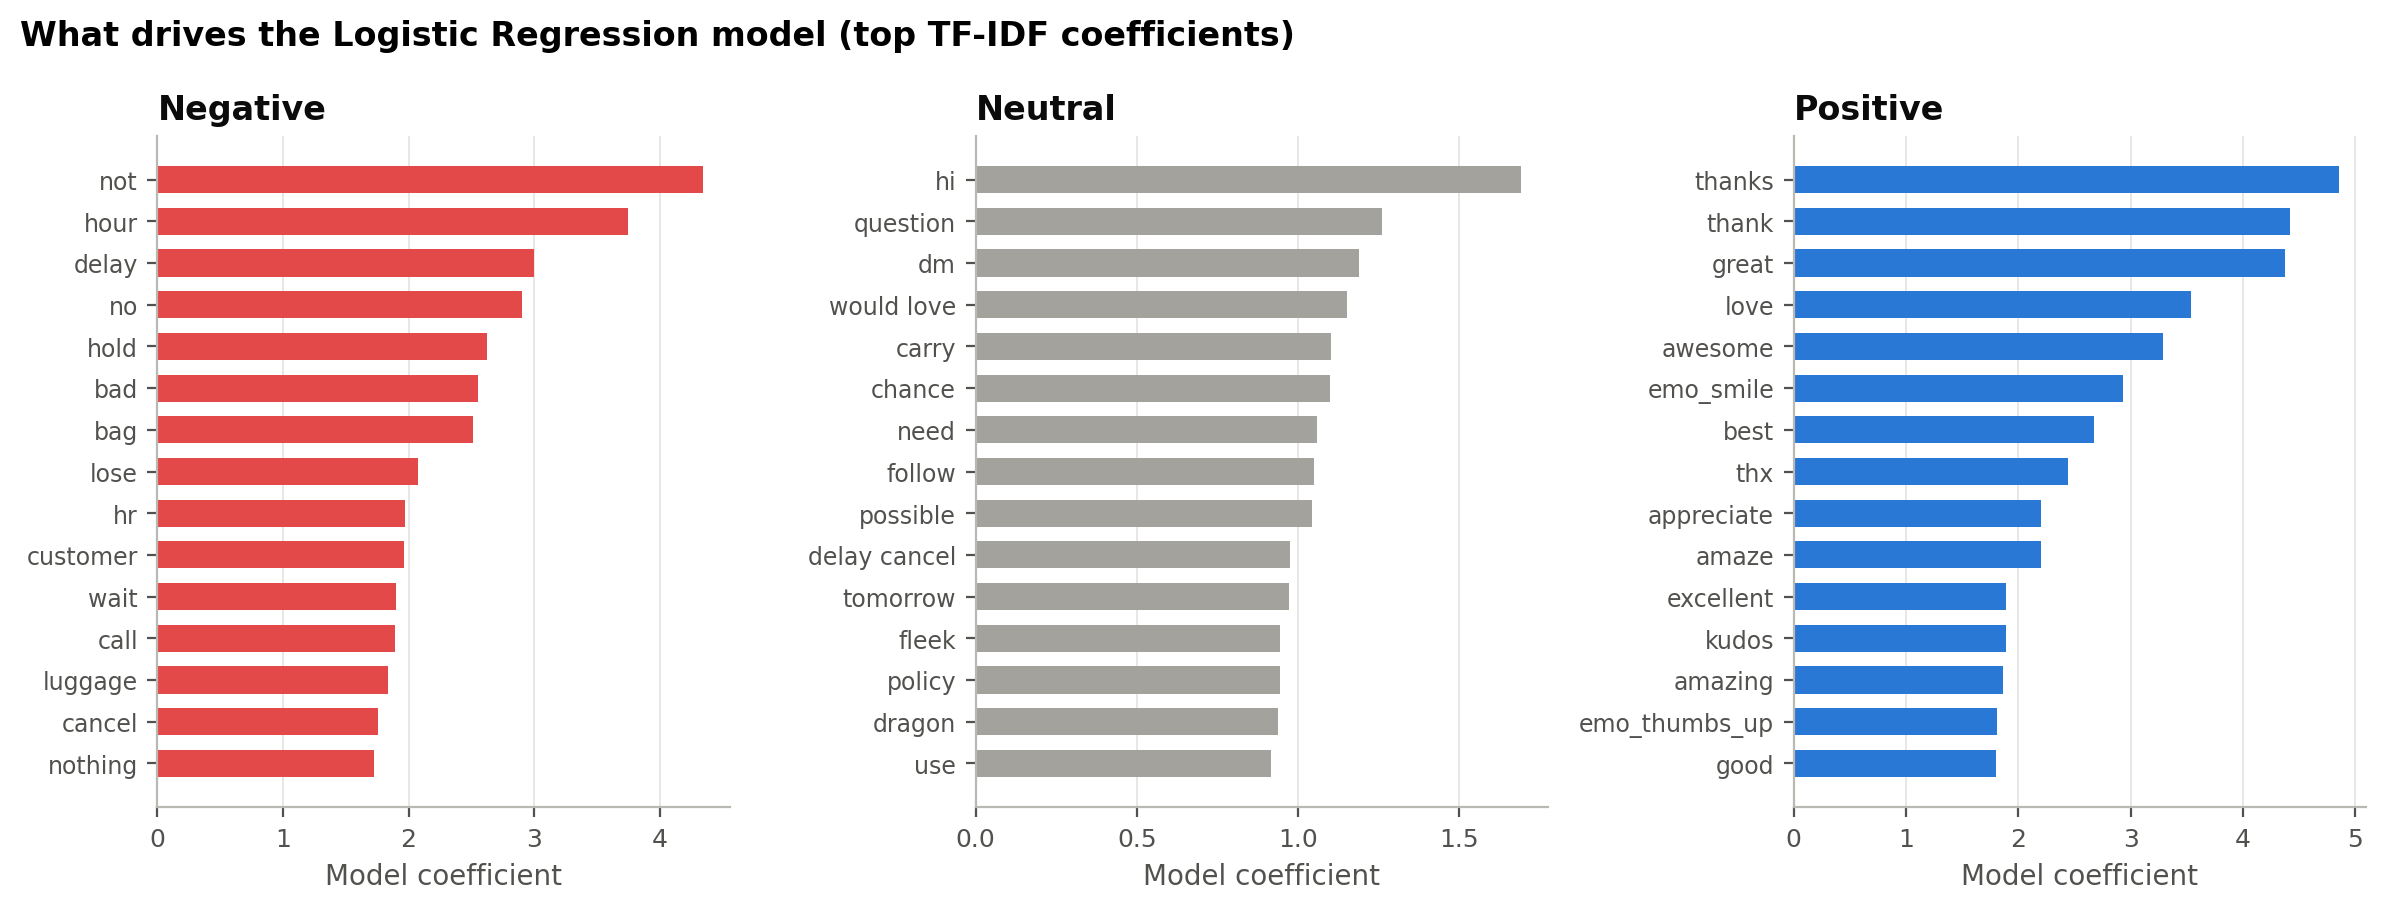

In [28]:
coefs = insights.top_coefficients(fitted["lr_tfidf"])
insights.fig_top_coefficients(coefs, "What drives the Logistic Regression model (top TF-IDF coefficients)",
                              FIG / "insight_top_coefficients.png")
show(FIG / "insight_top_coefficients.png")

### 6.2 Interpretation of Feature Associations

- These coefficients describe the Logistic Regression model, whereas the overall leading model is the word+character SVM. They should not be presented as a direct explanation of the SVM.
- Large coefficients indicate associations learned from this representation. Correlated terms, omitted context and annotation ambiguity prevent interpreting them as causal drivers of customer sentiment.


### 6.3 Airline-Level Sentiment Aggregation and Annotation Agreement


,n_test_tweets,actual_pct_negative,predicted_pct_negative,actual_nss,predicted_nss,abs_error_nss,actual_rank,predicted_rank
airline,,,,,,,,
US Airways,421,76.72,78.62,-69.60,-70.31,0.71,6,6
American,395,73.16,74.43,-62.28,-62.53,0.25,5,5
United,563,66.61,66.96,-54.17,-53.64,0.53,4,4
JetBlue,318,47.48,45.91,-23.27,-23.58,0.31,3,2
Southwest,393,48.35,51.40,-21.88,-25.19,3.31,2,3
Virgin America,83,42.17,43.37,-10.84,-15.66,4.82,1,1


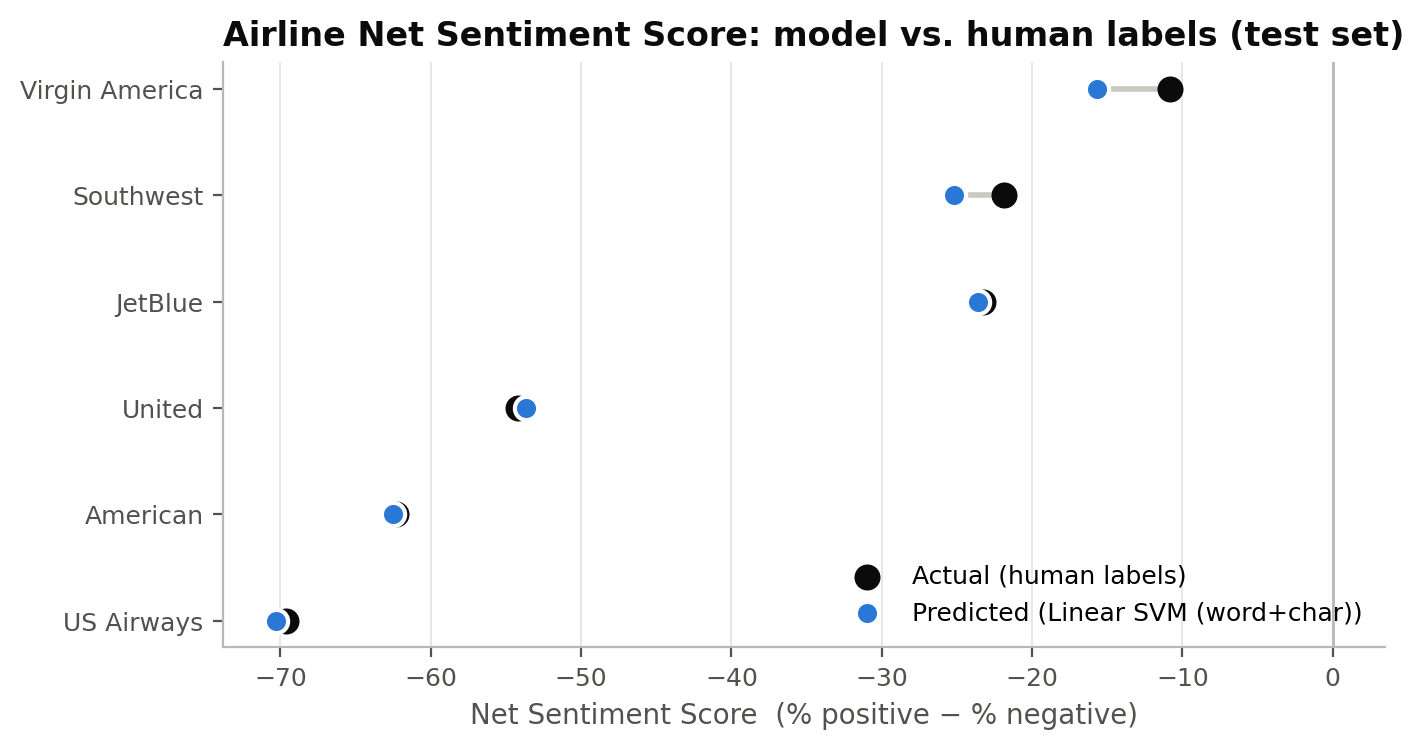

Predicted vs. human-labelled Net Sentiment Score: mean absolute error **1.7 points** (max 4.8). Airline ranking reproduced except for **JetBlue / Southwest**, whose actual scores differ by only 1.4 points.

In [29]:
best_merged = splits.test.merge(preds[best], on="tweet_id", validate="one_to_one")
kpis = insights.airline_kpis(best_merged)
kpis.to_csv(MET / "airline_kpis.csv")
display(kpis)
insights.fig_airline_kpis(kpis, names[best], FIG / "insight_airline_nss.png")
show(FIG / "insight_airline_nss.png")

swapped = kpis.index[kpis["actual_rank"] != kpis["predicted_rank"]].tolist()
display(Markdown(
    f"Predicted vs. human-labelled Net Sentiment Score: mean absolute error **{kpis['abs_error_nss'].mean():.1f} points** "
    f"(max {kpis['abs_error_nss'].max():.1f}). Airline ranking reproduced "
    + ("exactly." if not swapped else f"except for **{' / '.join(swapped)}**, whose actual scores differ by only "
       f"{kpis.loc[swapped, 'actual_nss'].max() - kpis.loc[swapped, 'actual_nss'].min():.1f} points.")))

### 6.4 Aggregate Sentiment Findings and Ranking Sensitivity

- Predicted Net Sentiment Score differs from the human-labelled value by about 1.7 points on average. Virgin America has the largest absolute error (4.82 points) and only 83 test tweets, making its estimate particularly sensitive to individual predictions.
- The predicted ranking swaps JetBlue and Southwest; their human-labelled scores differ by only 1.39 points. Small aggregate errors can still change rankings when airlines are close.
- These summaries describe the held-out Twitter sample. Net Sentiment Score here is based on sentiment labels and should not be interpreted as survey-based Net Promoter Score.


### 6.5 Exploratory Complaint-Triage Threshold Analysis


,target_recall,threshold,precision,recall,share_of_tweets_flagged
0,0.90,-0.1666,0.8574,0.9002,0.6585
1,0.95,-0.3352,0.8043,0.9501,0.7409
2,0.98,-0.5172,0.7506,0.9802,0.8191


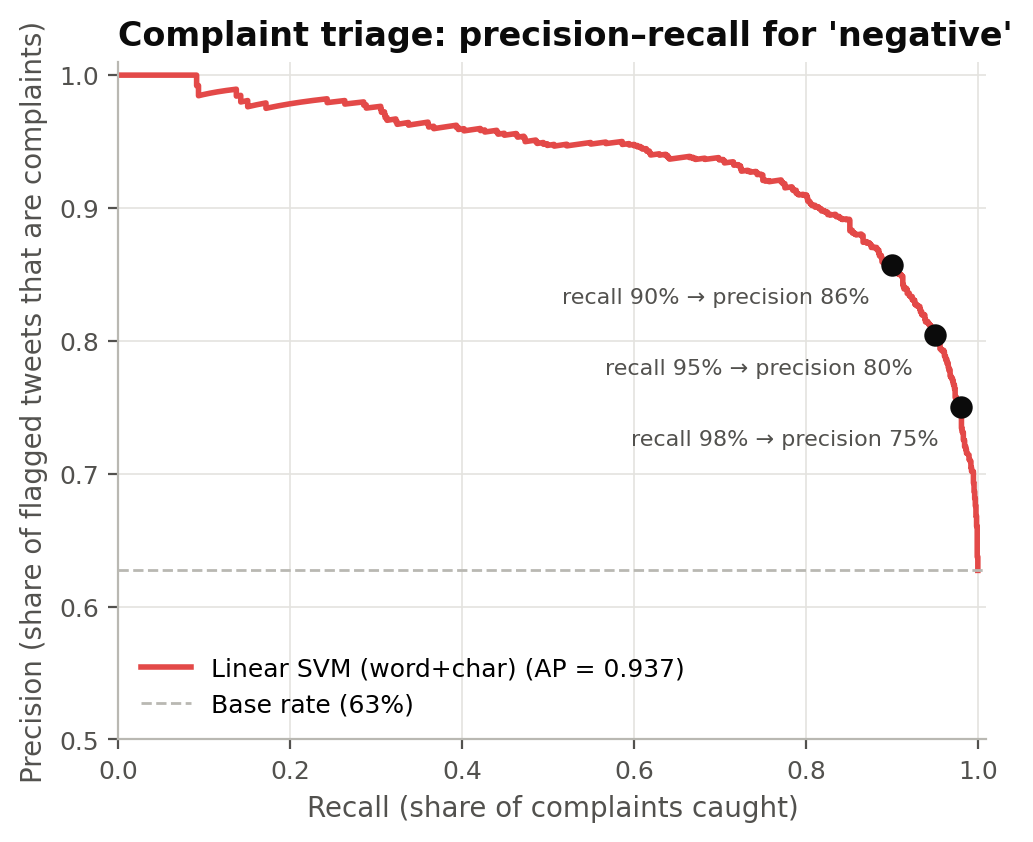

In [30]:
triage, curve = insights.negative_triage(best_merged)
triage.to_csv(MET / "negative_triage_operating_points.csv", index=False)
display(triage)
insights.fig_negative_pr(curve, triage, names[best], FIG / "insight_negative_pr.png")
show(FIG / "insight_negative_pr.png", width=600)

### 6.6 Complaint Detection, Precision, and Review Workload

- Increasing target negative recall from 90% to 98% lowers precision from 85.7% to 75.1% and increases the flagged share from 65.9% to 81.9%. Capturing more complaints therefore increases review workload and false alarms.
- At the approximately 95% recall point, precision is 80.4% and 74.1% of tweets are flagged. About one in five flagged tweets is not labelled negative.
- These thresholds were selected on test outcomes and are exploratory. Choose an operational threshold on validation or out-of-fold scores, then measure performance on fresh held-out data.


### 6.7 Performance Analysis by Complaint Category and Annotation Confidence


**Recall on negative tweets, by complaint reason**

,n,recall
negativereason,,
Can't Tell,181,0.751
Bad Flight,84,0.857
Flight Booking Problems,85,0.859
Customer Service Issue,440,0.895
Flight Attendant Complaints,85,0.906
Late Flight,250,0.924
Lost Luggage,86,0.930
Cancelled Flight,119,0.933
Damaged Luggage,7,1.000


**Accuracy by annotator confidence**

,model,slug,confidence_band,n,accuracy
0,Linear SVM (word+char),svm_word_char,< 0.60,34,0.4706
1,Linear SVM (word+char),svm_word_char,0.60–0.80,568,0.6215
2,Linear SVM (word+char),svm_word_char,0.80–0.99,6,1.0000
3,Linear SVM (word+char),svm_word_char,1.00 (maximum score),1565,0.8907
4,Linear SVM,svm_tfidf,< 0.60,34,0.4412
5,Linear SVM,svm_tfidf,0.60–0.80,568,0.6320
6,Linear SVM,svm_tfidf,0.80–0.99,6,1.0000
7,Linear SVM,svm_tfidf,1.00 (maximum score),1565,0.8728
8,Naive Bayes,nb_tfidf,< 0.60,34,0.4118
9,Naive Bayes,nb_tfidf,0.60–0.80,568,0.6039


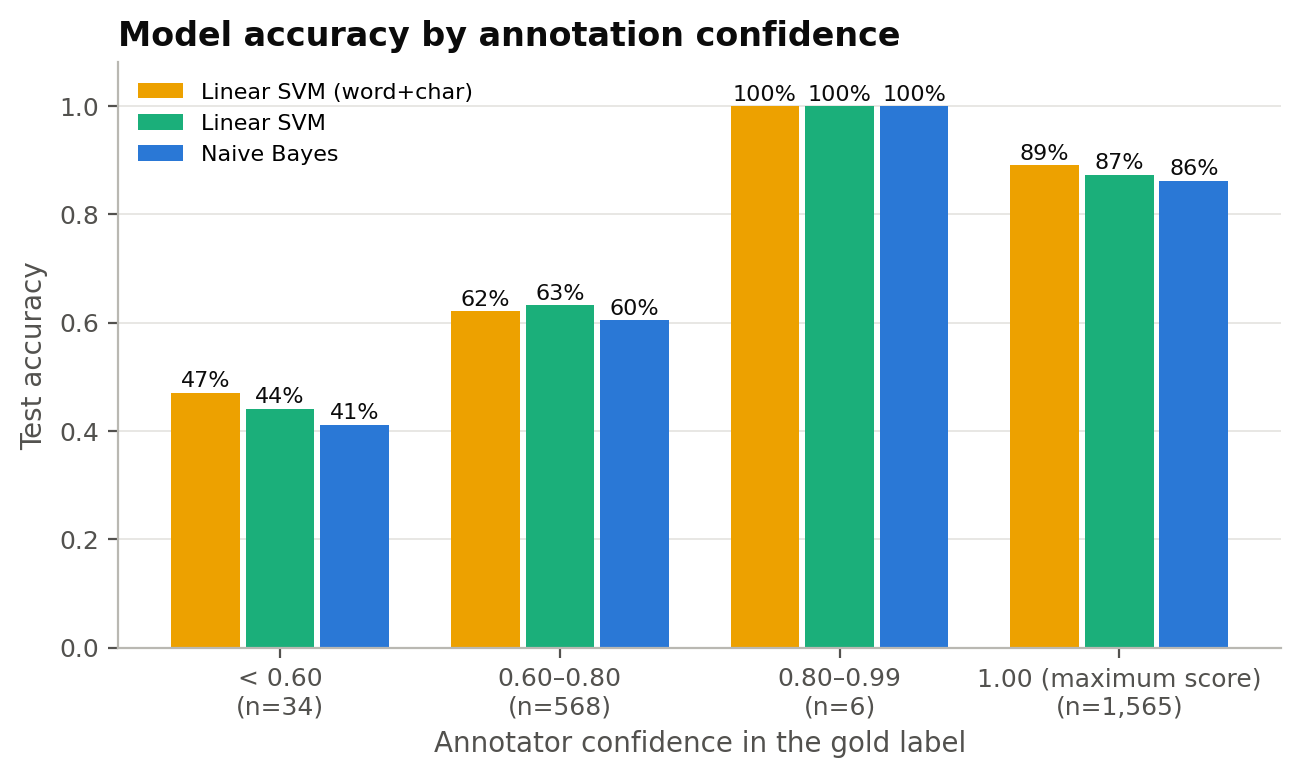

In [31]:
display(Markdown("**Recall on negative tweets, by complaint reason**"))
display(insights.recall_by_reason(best_merged))

compare = list(dict.fromkeys(s for s in (best, "svm_tfidf", "nb_tfidf") if s in preds))
acc_conf = insights.accuracy_by_confidence({s: splits.test.merge(preds[s], on="tweet_id") for s in compare}, names)
acc_conf.to_csv(MET / "accuracy_by_confidence.csv", index=False)
display(Markdown("**Accuracy by annotator confidence**"), acc_conf)
insights.fig_accuracy_by_confidence(acc_conf, FIG / "insight_accuracy_by_confidence.png")
show(FIG / "insight_accuracy_by_confidence.png", width=640)

### 6.8 Subgroup Performance and Annotation Uncertainty

- Negative recall is lower for *Can't Tell* (0.751, n = 181) than for explicit complaints such as Cancelled Flight (0.933, n = 119). Ambiguous complaint language deserves targeted error review.
- Perfect recall for Damaged Luggage (n = 7) and longlines (n = 26) rests on small samples and is not evidence of consistently perfect future performance. These figures evaluate negative sentiment detection, not reason classification.
- Leading-SVM accuracy is 89.1% for maximum-confidence annotations, versus 62.2% in the 0.60?0.80 band and 47.1% below 0.60. The association suggests that difficult or ambiguous labels are a major evaluation concern.
- The 0.80?0.99 band has only six tweets, so its 100% accuracy is unstable. Annotator confidence is separate from model confidence.


### 6.9 Qualitative Analysis of High-Margin Classification Errors


In [32]:
display(Markdown("**The best model's most confident mistakes**"))
insights.confident_errors(best_merged, n=10)

**The best model's most confident mistakes**

,tweet_id,airline,text,true,predicted,model_confidence,airline_sentiment_confidence
1790,567919531068391425,US Airways,@USAirways thank you,neutral,positive,1.9051,0.6737
652,569948758118526976,American,@AmericanAir Thank you,neutral,positive,1.9051,1.0000
173,569199095505690624,United,"@united All flights Cancelled Flighted :( Trip refunded without difficulty, staff extremely helpful, no complaints! ...",positive,negative,1.1049,0.6793
772,570093462738984961,American,@AmericanAir no not yet. Waiting to be connected to an agent,neutral,negative,1.1035,0.6907
939,569476889313562624,United,@united Thanks! Good to know.,neutral,positive,1.0749,0.6863
1192,568463644503240704,United,@united RES # 0167560070877 Fsqthg Thanks,neutral,positive,1.0459,1.0000
557,568521960088449025,JetBlue,@JetBlue I can't. I don't have acces to a phone rn. My iPhone broke. :/ would rather change it now then Late Flightr.,neutral,negative,0.9777,1.0000
2135,570298679250305024,American,@AmericanAir u r horrible.went online to Cancelled Flight flight-no button-4that.Called CS &amp;wait time 40 mins&am...,neutral,negative,0.9679,1.0000
1135,568818335200223232,United,@united can't wait!!! 787!!! @tpallini http://t.co/oDlall5eDH,positive,negative,0.9509,0.6746
830,569580671112388608,United,@united no thank you,neutral,positive,0.9236,0.6186


### 6.10 Ambiguity, Mixed Sentiment, and High-Margin Errors

- Short acknowledgments such as thank you are labelled neutral in some examples but predicted positive. Lexically positive wording does not always match the intended conversational sentiment.
- The positive example mentioning cancelled flights, a refund and helpful staff is predicted negative, illustrating mixed sentiment. The positive cannot wait example also shows that negation cues require context.
- Values above 1 in model_confidence confirm that these SVM scores are not probabilities. Large margins can still accompany errors; review ambiguous cases and calibrate scores before probability-based decisions.


### 6.11 Operational Recommendations

The results support evaluating word+character TF-IDF SVM as a practical baseline for airline feedback classification. Its leading overall macro-F1 and accuracy make it a useful candidate, while BiLSTM's stronger neutral recall illustrates that model choice also depends on the business cost of different errors.

1. **Pilot complaint triage with human review.** At an exploratory test-selected operating point, the SVM catches approximately 95% of negative tweets with 80.4% precision and flags 74.1% of test tweets. Select an operational threshold on validation or out-of-fold scores, then evaluate it on fresh data before using these figures for staffing.
2. **Investigate frequent complaint categories.** Use the annotated customer-service and delay themes to guide operational investigation. Measure whether any intervention improves outcomes; this analysis does not establish causal effects or return on investment.
3. **Improve neutral-class handling.** Review ambiguous and mixed-sentiment examples, assess annotation consistency and compare alternatives using class-specific metrics. Keep human oversight for consequential decisions. SVM margins require calibration before being interpreted as probabilities.
4. **Strengthen validation and reproducibility.** Use grouped text/user or chronological splits, record full search grids and library versions, and set the interpreter hash seed before startup. Compare pipelines with equal training-data budgets when isolating algorithm performance.
5. **Monitor performance over time.** The February 2015 Twitter sample does not represent all airline customers or current language. Audit new predictions and monitor drift. Transformer evaluation and aspect-based sentiment analysis remain potential extensions whose benefits must be measured.

### 6.12 Study Limitations and Threats to Validity

Thirteen distinct lowercased texts occur in both development and test sets despite disjoint tweet IDs. Classical models fit on 85% of the corpus, while neural models train on 70% and select checkpoints on 15%. Two saved search candidate counts differ from the current code grids, and their historical grid definitions are unavailable. These constraints limit independence, controlled model comparisons and exact reconstruction of the original searches. Airline summaries also inherit the existing Delta-to-JetBlue relabeling assumption.

## 7. Conclusion and Future Research Directions

This study compares six sentiment-classification configurations across Naive Bayes, Logistic Regression, Linear SVM and BiLSTM using the existing airline dataset. Word+character TF-IDF SVM performs best in the saved overall comparison, achieving 81.41% accuracy and macro-F1 0.7658. Neutral tweets remain the leading model's weakest class, and more complex models do not consistently improve overall performance in this experiment.

Sentiment predictions could support complaint routing and feedback monitoring, while existing complaint annotations identify themes for investigation. The findings justify a carefully evaluated pilot rather than immediate production claims. Independent threshold evaluation, stronger data splitting and ongoing human audits are the main next steps.


## References
* Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation, 10*(7), 1895–1923.
* Joachims, T. (1998). Text categorization with support vector machines: Learning with many relevant features. In *ECML-98* (pp. 137–142). Springer.
* Liu, Y., et al. (2019). RoBERTa: A robustly optimized BERT pretraining approach. *arXiv:1907.11692*.
* McCallum, A., & Nigam, K. (1998). A comparison of event models for naive Bayes text classification. *AAAI-98 Workshop on Learning for Text Categorization*.
* Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv:1301.3781*.
* Monroe, B. L., Colaresi, M. P., & Quinn, K. M. (2008). Fightin' words: Lexical feature selection and evaluation for identifying the content of political conflict. *Political Analysis, 16*(4), 372–403.
* Salton, G., & Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. *Information Processing & Management, 24*(5), 513–523.
* Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT. *arXiv:1910.01108*.
* Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks. *IEEE Transactions on Signal Processing, 45*(11), 2673–2681.
* Figure Eight. (2015). *Twitter US Airline Sentiment* [Data set]. Kaggle. https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment